## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Persiapan Data


## Import Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load datasets
from google.colab import drive
file_path = '/content/drive/MyDrive/final_project_ds/gym_churn_us.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


| Kolom                                 | Penjelasan                                                                                                                                              |
| ------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **gender**                            | Jenis kelamin pelanggan.                                                                                               |
| **Near_Location**                     | Menunjukkan apakah pelanggan tinggal atau bekerja **dekat dengan lokasi gym** .                                  |
| **Partner**                           | Apakah pelanggan datang atau mendaftar **bersama pasangan/teman**. Kadang menunjukkan ada program referral atau pasangan latihan. |
| **Promo_friends**                     | Menunjukkan apakah pelanggan **bergabung karena promosi teman** atau referral.                                                     |
| **Phone**                             | Apakah pelanggan **menyediakan nomor telepon** atau terhubung lewat aplikasi (kadang digunakan untuk komunikasi promosi).                               |
| **Contract_period**                   | Lama **periode kontrak keanggotaan**.                                                                            |
| **Group_visits**                      | Apakah pelanggan mengikuti kelas group             |
| **Age**                               | Umur pelanggan (dalam tahun).                                                                                                                           |
| **Avg_additional_charges_total**      | **Rata-rata total biaya tambahan** yang dikeluarkan pelanggan, seperti pembelian minuman, personal training, atau merchandise.                          |
| **Month_to_end_contract**             | Jumlah **bulan tersisa sebelum kontrak berakhir**. Biasanya pelanggan dengan kontrak hampir habis lebih berisiko churn.                                 |
| **Lifetime**                          | Lama pelanggan sudah menjadi anggota gym (dalam bulan).                                                                                                 |
| **Avg_class_frequency_total**         | **Rata-rata frekuensi kehadiran kelas atau gym secara keseluruhan**, selama periode keanggotaan.                                                        |
| **Avg_class_frequency_current_month** | **Frekuensi rata-rata kehadiran bulan ini**, untuk melihat apakah pelanggan masih aktif.                                                                |
| **Churn**                             | Status apakah pelanggan **berhenti (churn)** atau **masih aktif**. Biasanya: 1 = churn (berhenti), 0 = aktif.                                           |


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
df['Contract_period'].unique()

array([ 6, 12,  1])

In [ ]:
df['Month_to_end_contract'].unique()

array([ 5., 12.,  1.,  6.,  3., 10., 11.,  9.,  4.,  7.,  8.,  2.])

In [ ]:
# Remove the decimal part by converting to integer type
df['Month_to_end_contract'] = df['Month_to_end_contract'].astype(int)

In [ ]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5,3,1.630108,1.596237,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   int64  
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
print('No.of.rows:',df.shape[0])
print()
print('No.of.columns:',df.shape[1])
print()
print('Number columns:',df.select_dtypes(np.number).columns.values)
print()
print('Categorical columns:',df.select_dtypes('object').columns.values)

No.of.rows: 4000

No.of.columns: 14

Number columns: ['gender' 'Near_Location' 'Partner' 'Promo_friends' 'Phone'
 'Contract_period' 'Group_visits' 'Age' 'Avg_additional_charges_total'
 'Month_to_end_contract' 'Lifetime' 'Avg_class_frequency_total'
 'Avg_class_frequency_current_month' 'Churn']

Categorical columns: []


In [ ]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


## Data Preprocessing

### Check Duplicate

In [ ]:
# cek duplicate
df.duplicated().sum()

np.int64(0)

Karena hasil 0 maka tidak ada duplicate

### Missing Value

In [ ]:
df.isnull().sum()

,0
gender,0
Near_Location,0
Partner,0
Promo_friends,0
Phone,0
Contract_period,0
Group_visits,0
Age,0
Avg_additional_charges_total,0
Month_to_end_contract,0


Tidak terdapat Missing Value

In [ ]:
for column in df.columns: #melihat ada yang beda dari yang lain
    print(f"============= {column} =================")
    display(df[column].value_counts())
    print()

============= gender =================


,count
gender,
1,2041
0,1959



============= Near_Location =================


,count
Near_Location,
1,3381
0,619



============= Partner =================


...

,count
Avg_class_frequency_total,
0.000000,88
0.861898,1
1.299477,1
1.976985,1
1.671952,1
...,...
1.734371,1
1.783444,1
3.791391,1



============= Avg_class_frequency_current_month =================


,count
Avg_class_frequency_current_month,
0.000000,181
0.823887,1
0.628353,1
2.628932,1
1.797684,1
...,...
1.047047,1
1.799264,1
1.711822,1



============= Churn =================


,count
Churn,
0,2939
1,1061


Tidak ada inconsistent naming

### Check Outlier

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   int64  
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

==================== gender ====================


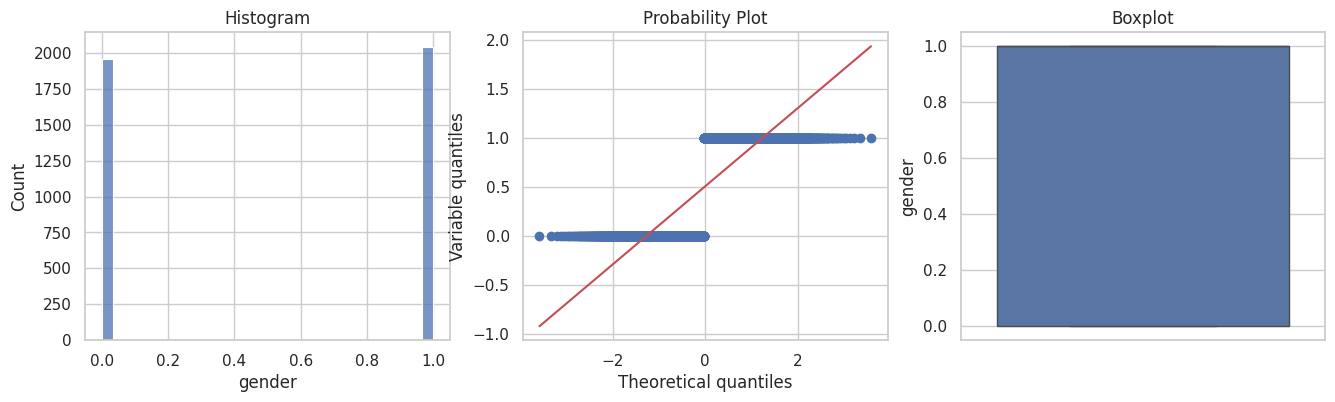

==================== Near_Location ====================


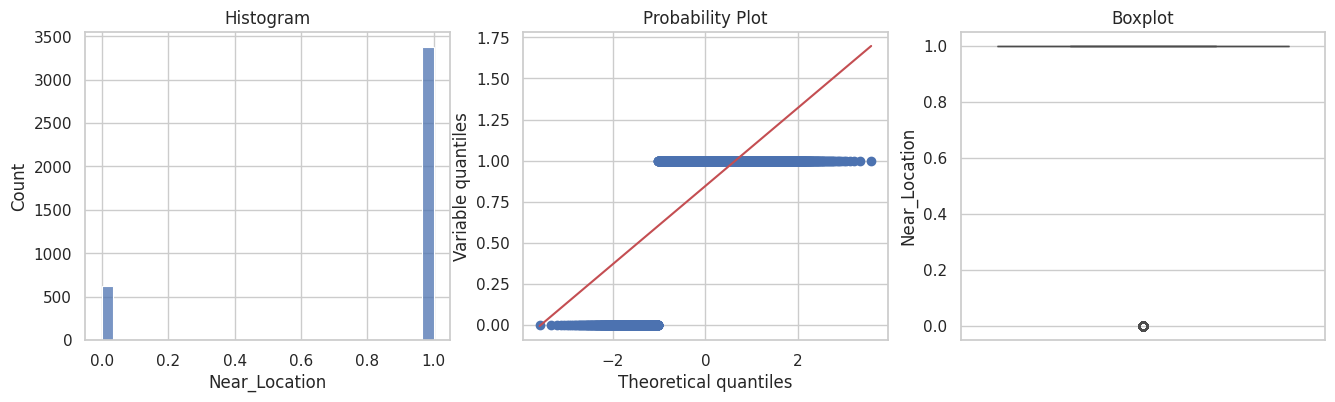

==================== Partner ====================


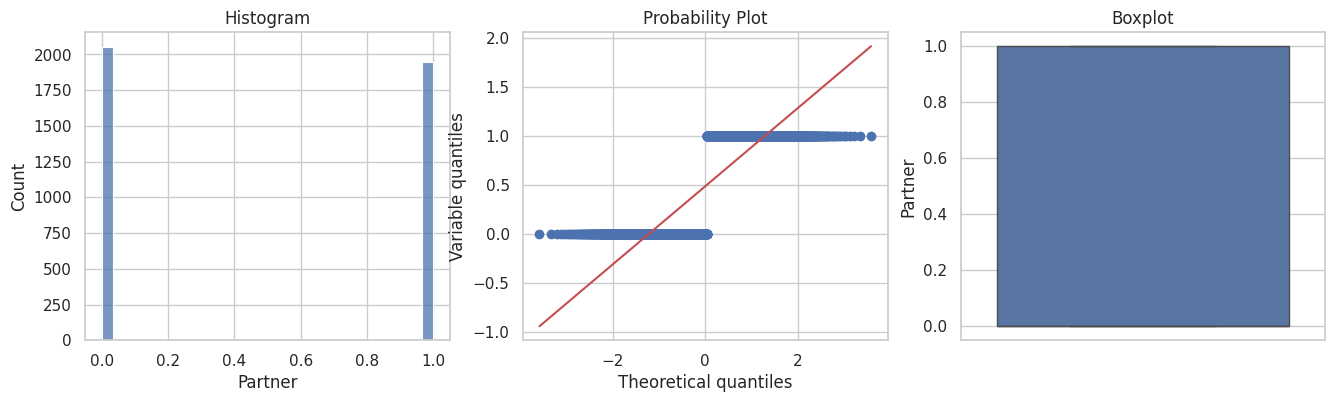

==================== Promo_friends ====================


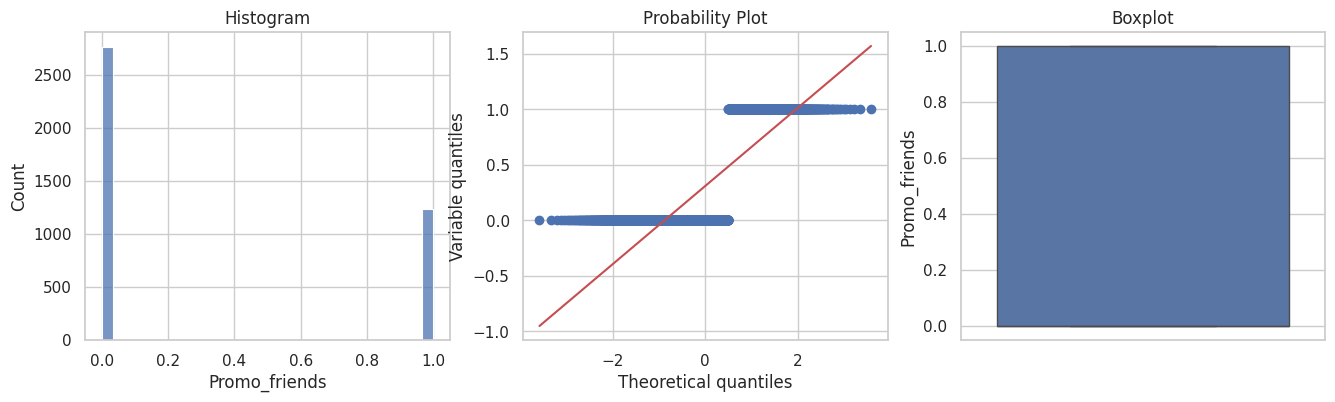

==================== Phone ====================


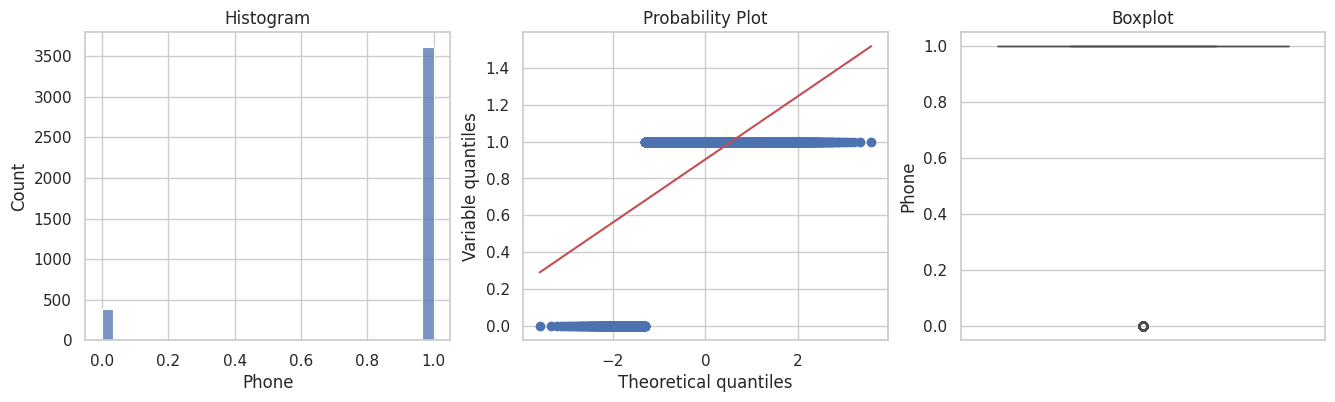

==================== Contract_period ====================


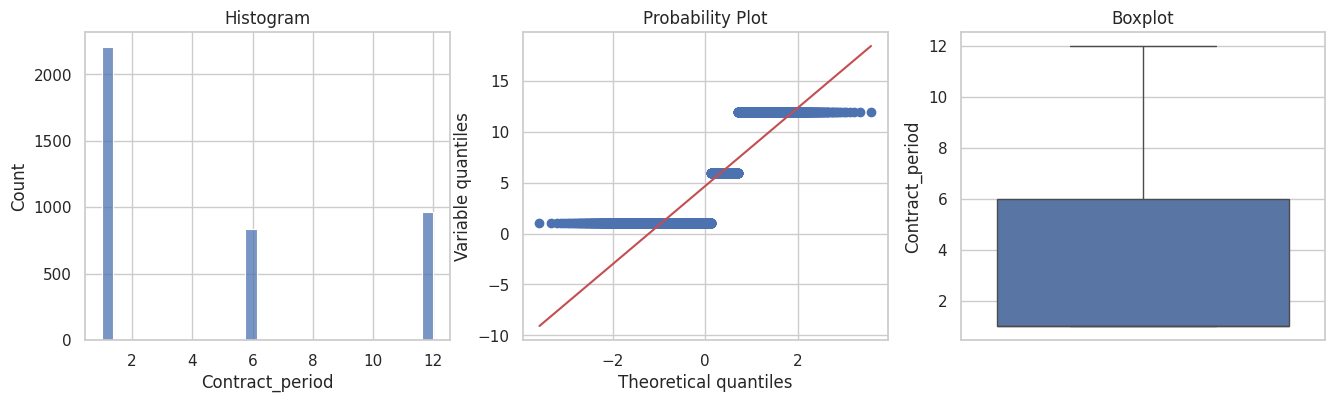

==================== Group_visits ====================


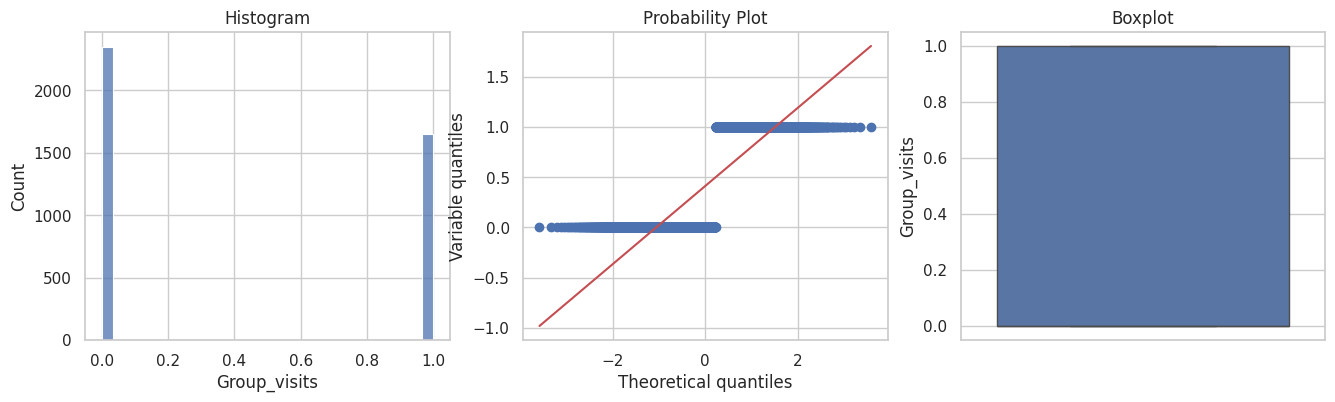

==================== Age ====================


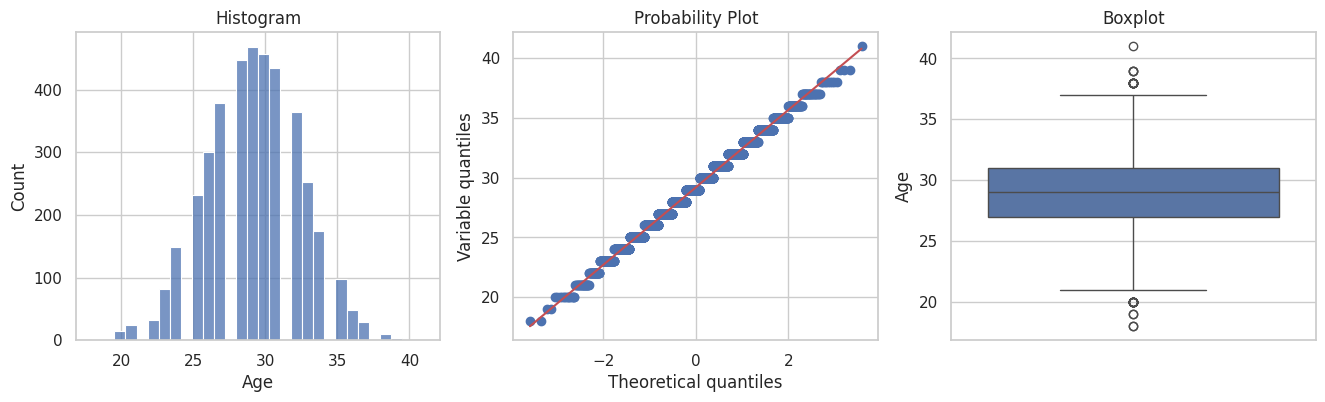

==================== Avg_additional_charges_total ====================


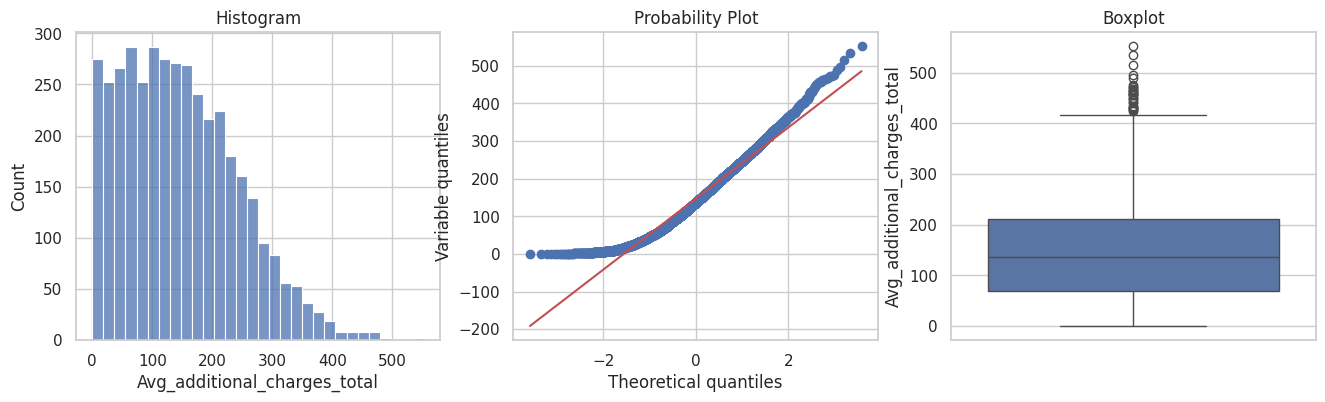

==================== Month_to_end_contract ====================


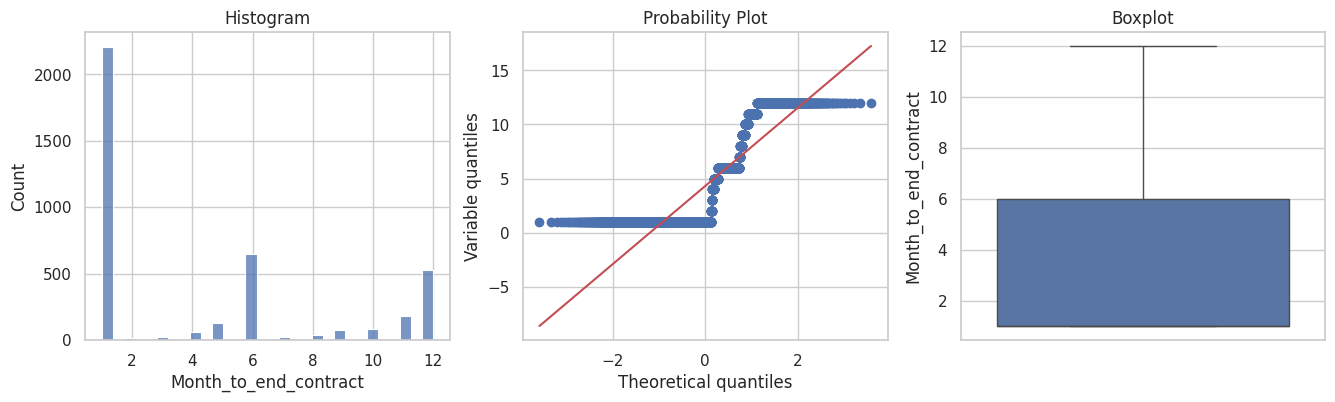

==================== Lifetime ====================


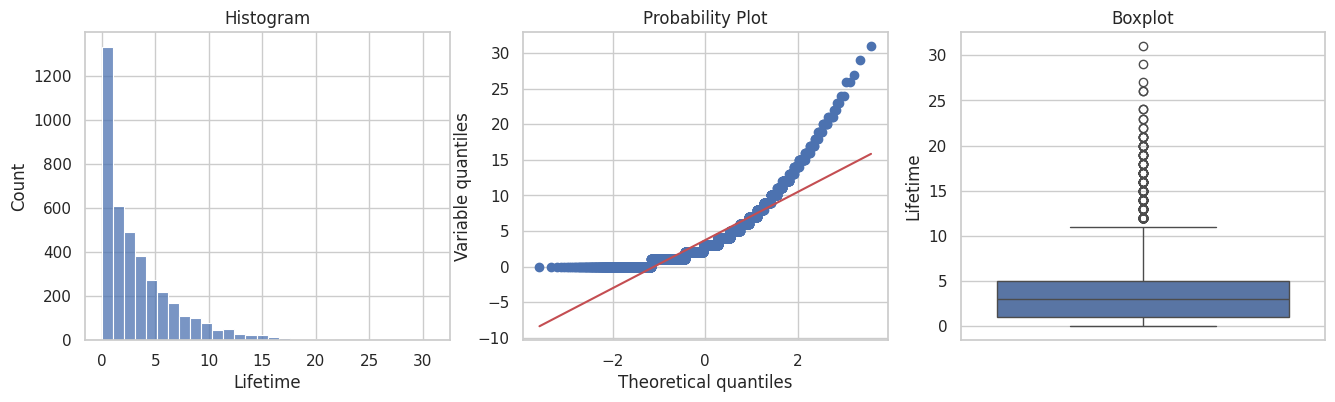

==================== Avg_class_frequency_total ====================


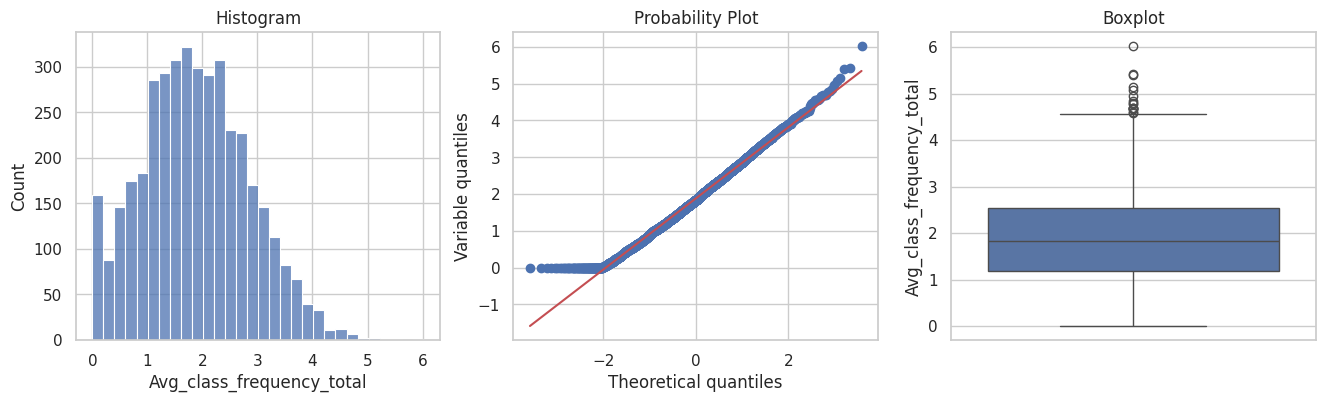

==================== Avg_class_frequency_current_month ====================


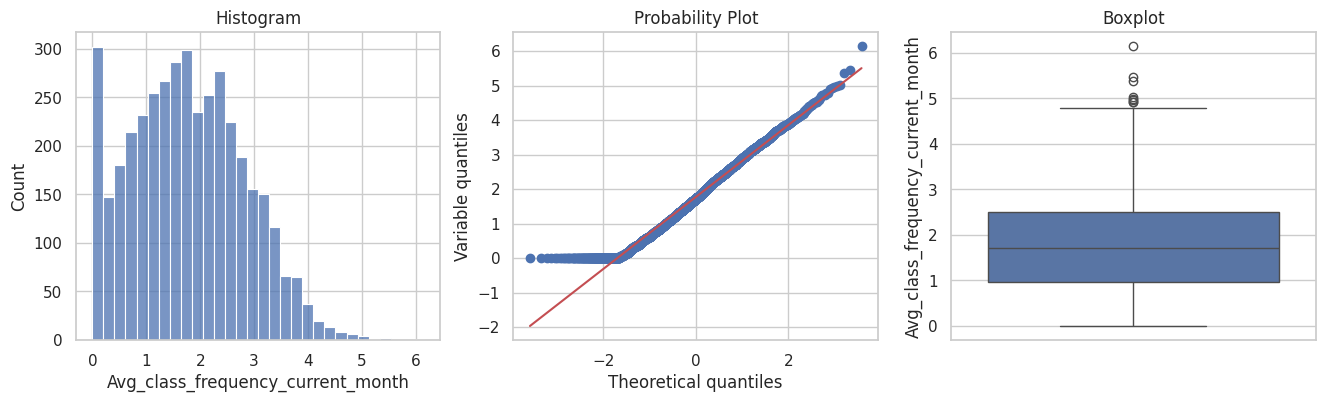

==================== Churn ====================


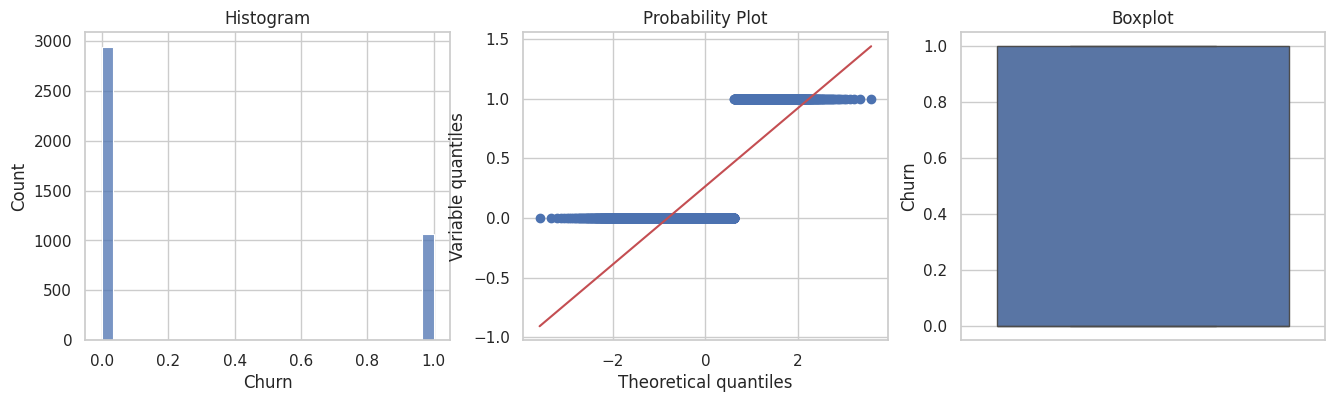

In [ ]:
# Get numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
for i in numeric_cols:
  print(f"==================== {i} ====================")
  check_plot(df, i)

 Terdapat outlier tp karena masih di dalam value jadi tidak di drop

In [ ]:
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

In [ ]:
#cek korelasi
df.corr()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


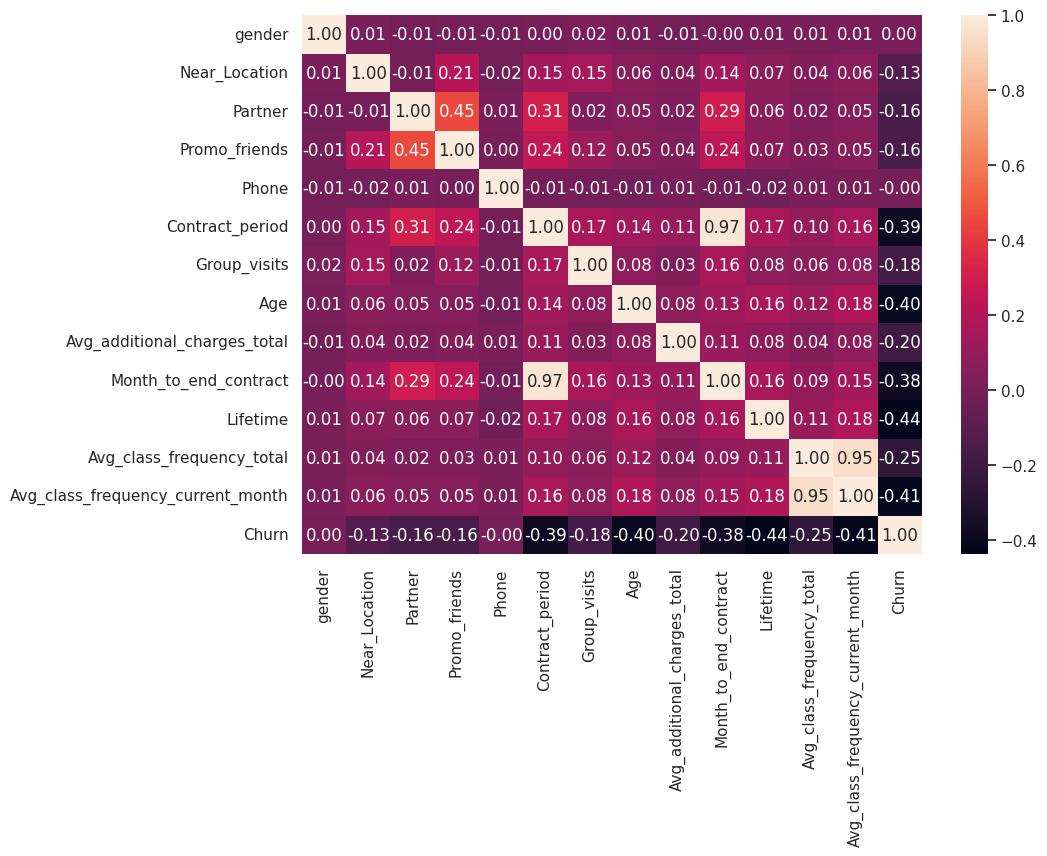

In [ ]:
#cek korelasi dengan heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.show()

#EDA

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,2939
1,1061


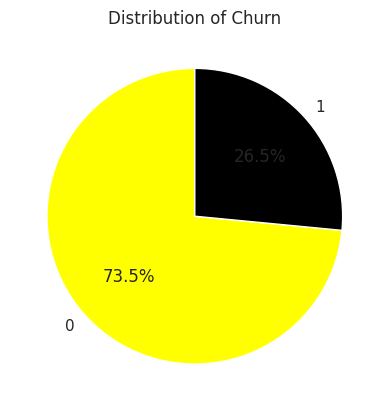

In [ ]:
# check target class distribution
df['Churn'].value_counts().plot(kind = 'pie', autopct='%1.1f%%', startangle=90, colors=['yellow', 'black'])
plt.title('Distribution of Churn')
plt.ylabel('') # Remove default y-label for pie chart
plt.show()

many customer still retained their subscription, from this eda we want to know what makes the customer still retained

In [ ]:
print('Number columns:',df.select_dtypes(np.number).columns.values)
print()
print('Categorical columns:',df.select_dtypes('object').columns.values)
print()

Number columns: ['gender' 'Near_Location' 'Partner' 'Promo_friends' 'Phone'
 'Contract_period' 'Group_visits' 'Age' 'Avg_additional_charges_total'
 'Month_to_end_contract' 'Lifetime' 'Avg_class_frequency_total'
 'Avg_class_frequency_current_month' 'Churn']

Categorical columns: []



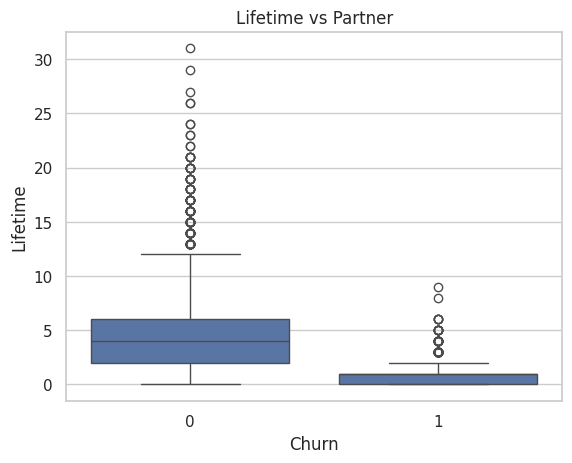

In [ ]:
sns.boxplot(x='Churn', y='Lifetime', data=df)
plt.title('Lifetime vs churn')
plt.show()

the averanger lifetime ofloyal customer slighly higher than the churn customer

In [ ]:
avg_lifetime = df.groupby("Churn")["Lifetime"].mean()
avg_lifetime

,Lifetime
Churn,
0,4.711807
1,0.990575


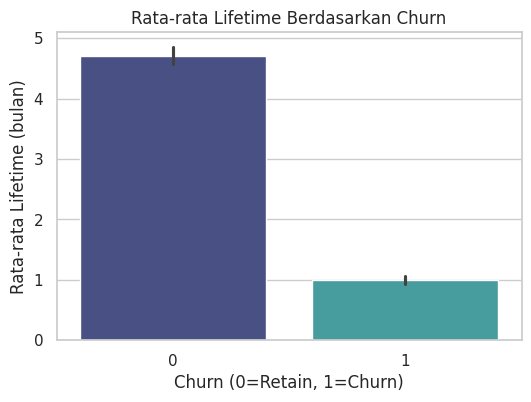

In [ ]:
#buat grafik barplot rata2 lifetime dari kolom churn
# Visualisasi
plt.figure(figsize=(6,4))
sns.barplot(x=df['Churn'], y=df['Lifetime'], palette="mako")
plt.title("Rata-rata Lifetime Berdasarkan Churn")
plt.xlabel("Churn (0=Retain, 1=Churn)")
plt.ylabel("Rata-rata Lifetime (bulan)")
plt.show()

## Loyal EDA

In [ ]:
loyal = df[df['Churn'] == 0]
print(f"Jumlah pelanggan loyal: {len(loyal)} ({len(loyal)/len(df)*100:.1f}%) dari total data")

Jumlah pelanggan loyal: 2939 (73.5%) dari total data


###loyal dengan gender

In [ ]:
#melihat loayal dengan gender
loyal['gender'].value_counts()

,count
gender,
1,1499
0,1440


### loyal dengan near location

In [ ]:
#loyal dengan near locarion
loyal['Near_Location'].value_counts()

,count
Near_Location,
1,2566
0,373


<Axes: title={'center': 'loyal dengan near location'}, ylabel='count'>

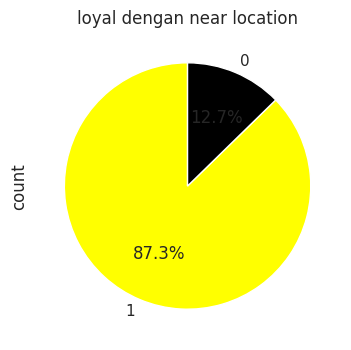

In [ ]:
#buatkan piechartnya
plt.figure(figsize=(7,4))
plt.title('loyal dengan near location')
loyal['Near_Location'].value_counts().plot(kind = 'pie', autopct='%1.1f%%', startangle=90, colors=['yellow', 'black'])

many loyal customer lives near the gym location

### loyal dengan avg class frequency total

In [ ]:
#loyal dengan avg class frequency total
loyal['Avg_class_frequency_total'].value_counts()

,count
Avg_class_frequency_total,
0.000000,68
3.077303,1
0.135178,1
1.447308,1
2.272211,1
...,...
2.341545,1
0.999179,1
1.734371,1


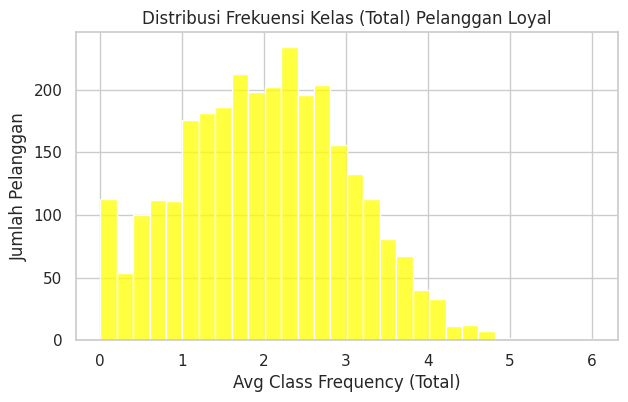

In [ ]:
#buatkan barchartnya
plt.figure(figsize=(7,4))
sns.histplot(x='Avg_class_frequency_total', data=loyal, color='yellow')
plt.title('Distribusi Frekuensi Kelas (Total) Pelanggan Loyal')
plt.xlabel('Avg Class Frequency (Total)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

the averange class frequency from the customer are in range of 1-3 times

###loyal dengan promo friends

In [ ]:
#loyal dan promo friends
loyal['Promo_friends'].value_counts()

,count
Promo_friends,
0,1900
1,1039


<Axes: title={'center': 'loyal dengan promo friends'}, ylabel='count'>

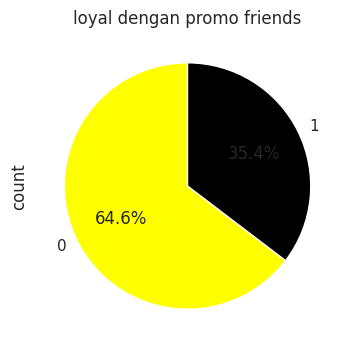

In [ ]:
#BUATKNA Pichartnya dengan judul loyal yang menggunakan promo friends

plt.figure(figsize=(7,4))
plt.title('loyal dengan promo friends')
loyal['Promo_friends'].value_counts().plot(kind = 'pie', autopct='%1.1f%%', startangle=90, colors=['yellow', 'black'])

even the loyal customer mostly not using friends promo for the subscriptions, but still the promo affected the customer retain as we look from the pie chart 35% using it.

###loyal dengan contract period

In [ ]:
#loyal dengan contract period
loyal['Contract_period'].value_counts()

,count
Contract_period,
1,1273
12,937
6,729


Text(0.5, 0, 'Contract Period (bulan)')

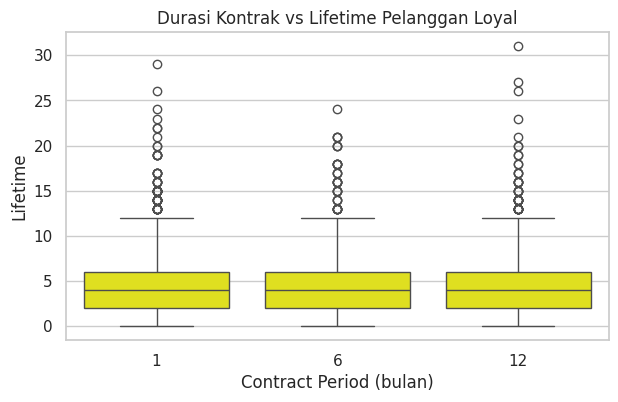

In [ ]:
#berikan boxplotnya
plt.figure(figsize=(7,4))
sns.boxplot(data=loyal, x='Contract_period', y='Lifetime', color='yellow')
plt.title('Durasi Kontrak vs Lifetime Pelanggan Loyal')
plt.xlabel('Contract Period (bulan)')

there is no difference lifetime betweent contract type

###loyal dengan group visit

In [ ]:
#loyal dengan group visit
loyal['Group_visits'].value_counts()

,count
Group_visits,
0,1575
1,1364


<Axes: title={'center': 'loyal dengan group visits'}, ylabel='count'>

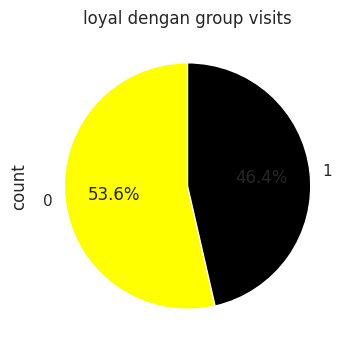

In [ ]:
#Buatkan piechartnya
plt.figure(figsize=(7,4))
plt.title('loyal dengan group visits')
loyal['Group_visits'].value_counts().plot(kind = 'pie', autopct='%1.1f%%', startangle=90, colors=['yellow', 'black'])

there are 46% loyal customer like to join the group classes (ex yoga, muathai class)

###loyal dengan age

In [ ]:
#loyal dengan age
loyal['Age'].value_counts()


,count
Age,
31,378
30,376
29,349
32,328
28,311
27,239
33,236
26,167
34,166


Text(0, 0.5, 'Jumlah Pelanggan')

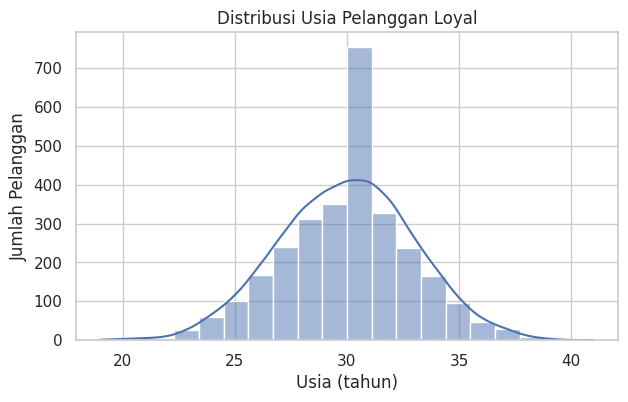

In [ ]:
#buatkan barplotnya
plt.figure(figsize=(7,4))
sns.histplot(loyal['Age'], bins=20, kde=True)
plt.title('Distribusi Usia Pelanggan Loyal')
plt.xlabel('Usia (tahun)')
plt.ylabel('Jumlah Pelanggan')

the avg people subscribe are in 325-35 years old

###loyal dan avg additional charge total

In [ ]:
#loyal dan avg additional charge total
loyal['Avg_additional_charges_total'].value_counts()

,count
Avg_additional_charges_total,
178.861814,1
14.227470,1
113.202938,1
129.448479,1
62.669863,1
...,...
97.804315,1
92.787414,1
11.975295,1


In [ ]:
#melihat yang avg addtional charges total terkecil dari loyal
loyal[loyal['Avg_additional_charges_total'] == loyal['Avg_additional_charges_total'].min()]

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3494,0,1,0,0,1,1,1,29,0.171862,1,1,2.000838,1.831822,0


Text(0.5, 0, 'Avg Additional Charges Total')

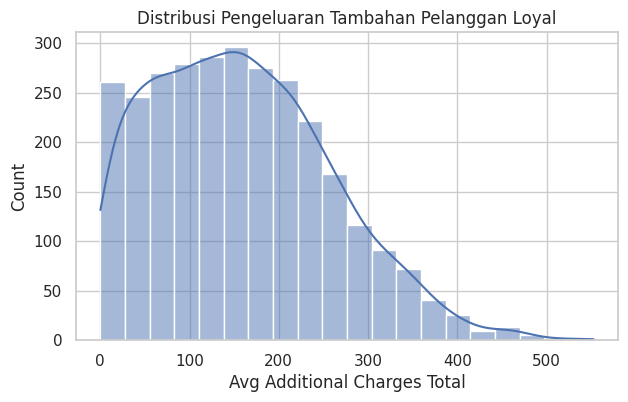

In [ ]:
#buatkan barchartnya
plt.figure(figsize=(7,4))
sns.histplot(loyal['Avg_additional_charges_total'], bins=20, kde=True)
plt.title('Distribusi Pengeluaran Tambahan Pelanggan Loyal')
plt.xlabel('Avg Additional Charges Total')

many loyal customer spend additional charges (outside the subscription fee) between 50-200 dollars

###Distribusi Lifetime pelanggan loyal

In [ ]:
#melihat distribusi lifetime pelanggan loyal dalam tabel
loyal['Lifetime'].value_counts().sort_index()

,count
Lifetime,
0,84
1,429
2,453
3,440
4,360
5,265
6,216
7,167
8,110


In [ ]:
df['Lifetime'].unique()

array([ 3,  7,  2,  0,  1, 11,  4,  8, 14,  6,  5, 15, 12, 21, 10, 20,  9,
       13, 17, 16, 24, 22, 31, 26, 23, 18, 19, 27, 29])

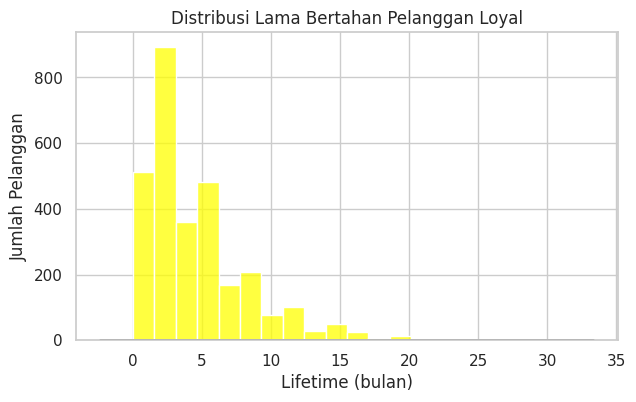

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))

# Histogram kuning (tanpa KDE)
sns.histplot(loyal['Lifetime'], bins=20, kde=False, color='yellow')

# KDE hitam di atas histogram
sns.kdeplot(loyal['Lifetime'], bw_method='scott', linewidth=1.5, color='black')

plt.title('Distribusi Lama Bertahan Pelanggan Loyal')
plt.xlabel('Lifetime (bulan)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

the lifetime of loyal customer still in 1-5 months

###loyal near location dengan avg class frequency total

In [ ]:
#loyal near location dengan avg class frequency total
loyal_near_freq_counts = loyal.groupby('Near_Location')['Avg_class_frequency_total'].value_counts().reset_index(name='count')
loyal_near_freq_counts

,Near_Location,Avg_class_frequency_total,count
0,0,0.000000,5
1,0,0.053519,1
2,0,0.125256,1
3,0,0.141387,1
4,0,0.161426,1
...,...,...,...
2868,1,5.079242,1
2869,1,5.141852,1
2870,1,5.410054,1
2871,1,5.421898,1


In [ ]:
bins = [0, 1, 3, loyal['Avg_class_frequency_total'].max()]
labels = ['Rendah (0–1)', 'Sedang (1–3)', 'Tinggi (>3)']
loyal['freq_category'] = pd.cut(loyal['Avg_class_frequency_total'], bins=bins, labels=labels, include_lowest=True)


In [ ]:
loyal.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,freq_category
0,1,1,1,1,0,6,1,29,14.227470,5,3,0.020398,0.000000,0,Rendah (0–1)
1,0,1,0,0,1,12,1,31,113.202938,12,7,1.922936,1.910244,0,Sedang (1–3)
2,0,1,1,0,1,1,0,28,129.448479,1,2,1.859098,1.736502,0,Sedang (1–3)
3,0,1,1,1,1,12,1,33,62.669863,12,2,3.205633,3.357215,0,Tinggi (>3)
4,1,1,1,1,1,1,0,26,198.362265,1,3,1.113884,1.120078,0,Sedang (1–3)


In [ ]:
agg_df = loyal.groupby(['Near_Location', 'freq_category']).size().reset_index(name='count')
agg_df

,Near_Location,freq_category,count
0,0,Rendah (0–1),56
1,0,Sedang (1–3),249
2,0,Tinggi (>3),68
3,1,Rendah (0–1),433
4,1,Sedang (1–3),1686
5,1,Tinggi (>3),447


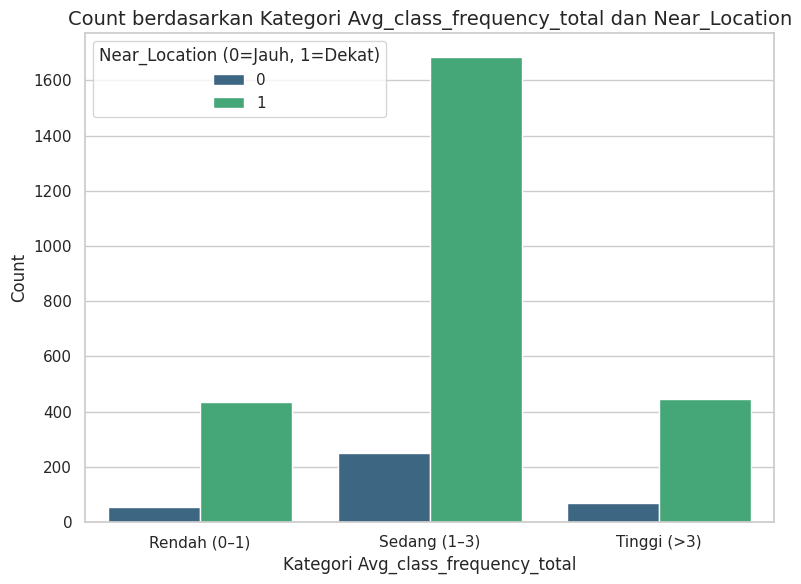

In [ ]:
#buatkan barplotnya loyal near location dengan avg class frequency total
plt.figure(figsize=(8,6))
sns.barplot(
    data=agg_df,
    x='freq_category',
    y='count',
    hue='Near_Location',
    palette='viridis'
)

plt.title('Count berdasarkan Kategori Avg_class_frequency_total dan Near_Location', fontsize=14)
plt.xlabel('Kategori Avg_class_frequency_total')
plt.ylabel('Count')
plt.legend(title='Near_Location (0=Jauh, 1=Dekat)')
plt.tight_layout()
plt.show()

the middle avg near location loyal customer (1-3) are dominating

### loyal near location dengan partner

In [ ]:
#loyal near location dengan partner
loyal_near_partner_counts = loyal.groupby('Near_Location')['Partner'].value_counts().reset_index(name='count')
loyal_near_partner_counts

,Near_Location,Partner,count
0,0,1,207
1,0,0,166
2,1,1,1363
3,1,0,1203


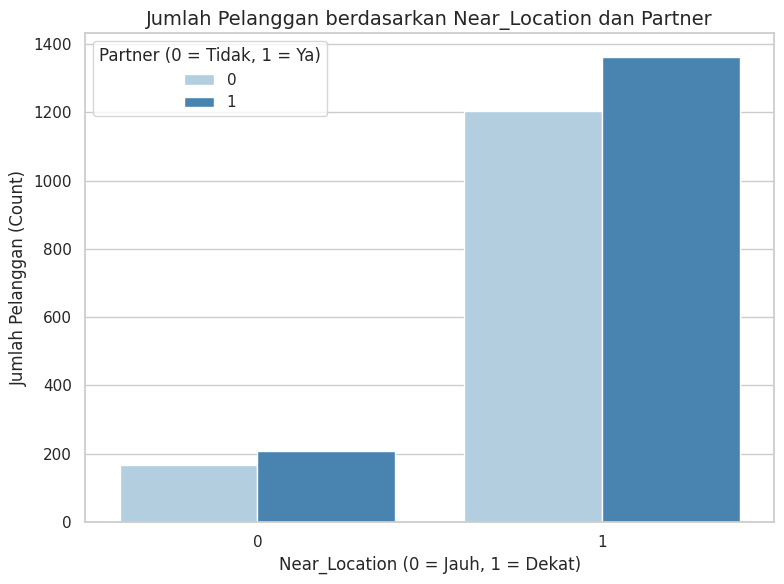

In [ ]:
#buatkan barplotnya loyal near location dengan partner
plt.figure(figsize=(8,6))
sns.barplot(
    data=loyal_near_partner_counts,
    x='Near_Location',
    y='count',
    hue='Partner',
    palette='Blues'
)

plt.title('Jumlah Pelanggan berdasarkan Near_Location dan Partner', fontsize=14)
plt.xlabel('Near_Location (0 = Jauh, 1 = Dekat)')
plt.ylabel('Jumlah Pelanggan (Count)')
plt.legend(title='Partner (0 = Tidak, 1 = Ya)')
plt.tight_layout()
plt.show()

neat-location loyal customer are likely to join with partner.

###loyal promo friends and near location

In [ ]:
#loyal near location dengan promo
loyal_near_promo_counts = loyal.groupby('Near_Location')['Promo_friends'].value_counts().reset_index(name='count')
loyal_near_promo_counts

,Near_Location,Promo_friends,count
0,0,0,334
1,0,1,39
2,1,0,1566
3,1,1,1000


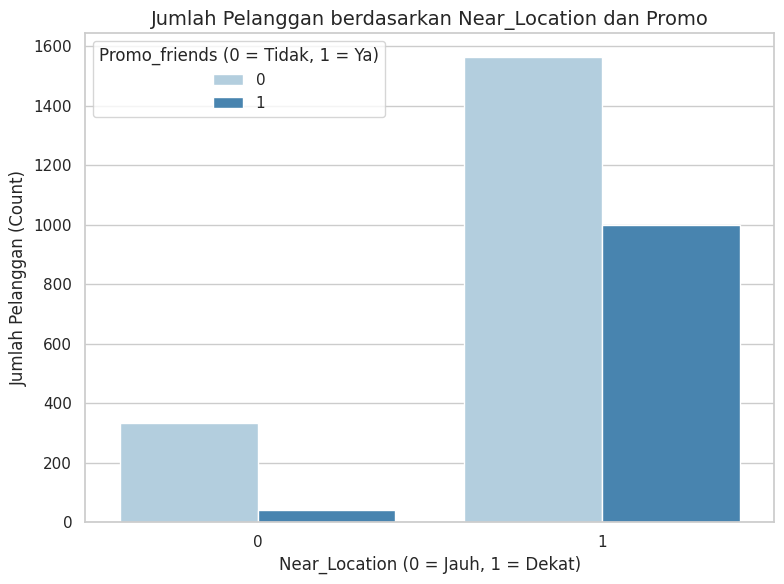

In [ ]:
#buatkan barplotnya loyal near location dengan Promo_friends
plt.figure(figsize=(8,6))
sns.barplot(
    data=loyal_near_promo_counts,
    x='Near_Location',
    y='count',
    hue='Promo_friends',
    palette='Blues'
)

plt.title('Jumlah Pelanggan berdasarkan Near_Location dan Promo', fontsize=14)
plt.xlabel('Near_Location (0 = Jauh, 1 = Dekat)')
plt.ylabel('Jumlah Pelanggan (Count)')
plt.legend(title='Promo_friends (0 = Tidak, 1 = Ya)')
plt.tight_layout()
plt.show()

###loyal lifetime dengan avg class freq total

“Apakah pelanggan yang lebih sering ikut kelas cenderung bertahan lebih lama?”

In [ ]:
#loyal lifetime dengan avg class freq total
loyal_lifetime_freq_counts = loyal.groupby('Lifetime')['Avg_class_frequency_total'].value_counts().reset_index(name='count')
loyal_lifetime_freq_counts

,Lifetime,Avg_class_frequency_total,count
0,0,0.000000,4
1,0,0.392670,1
2,0,0.467158,1
3,0,0.530804,1
4,0,0.545473,1
...,...,...,...
2881,26,1.202611,1
2882,26,1.663034,1
2883,27,0.000000,1
2884,29,1.750208,1


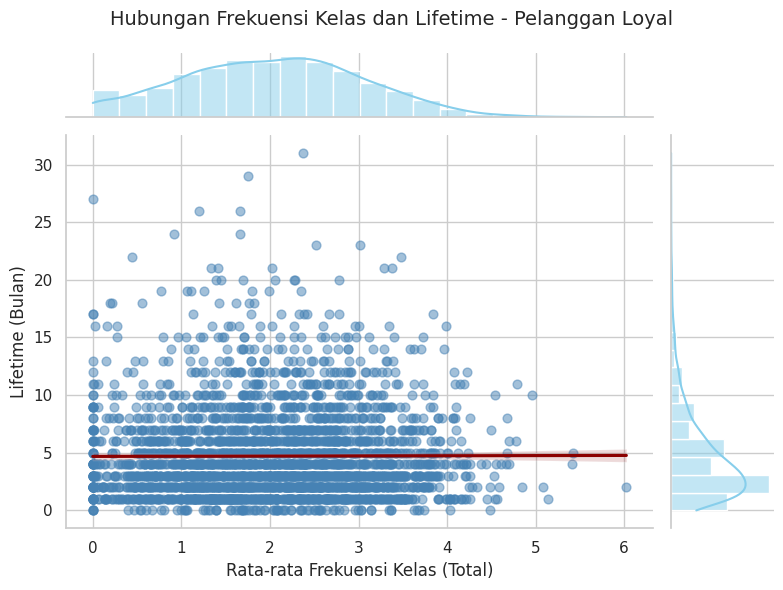

In [ ]:
g = sns.jointplot(
    data=loyal,
    x='Avg_class_frequency_total',
    y='Lifetime',
    kind='reg',              # ada garis tren linear
    scatter_kws={'alpha':0.5, 's':40, 'color':'steelblue'},
    line_kws={'color':'darkred'},
    marginal_kws={'bins':20, 'fill':True, 'color':'skyblue'}
)

# Atur ukuran dan judul
g.fig.set_size_inches(8, 6)
g.fig.suptitle('Hubungan Frekuensi Kelas dan Lifetime - Pelanggan Loyal', fontsize=14)
g.set_axis_labels('Rata-rata Frekuensi Kelas (Total)', 'Lifetime (Bulan)', fontsize=12)
plt.tight_layout()
plt.show()


- Sebagian besar pelanggan loyal memiliki lifetime di bawah 10 bulan.
Terlihat titik-titik banyak terkumpul di bawah garis y < 10, menandakan walaupun mereka dikategorikan “loyal”, durasi bertahannya tidak selalu panjang.

- Rata-rata frekuensi kelas (0–3 kali per bulan) paling umum di antara pelanggan loyal.
Distribusi di atas sumbu X menunjukkan mayoritas loyal customers punya intensitas kelas rendah–sedang.

- Hubungan antara frekuensi kelas dan lifetime hampir datar (garis regresi merah mendekati horizontal).
➤ Ini berarti tidak ada korelasi kuat antara seberapa sering ikut kelas dan berapa lama pelanggan bertahan.
Dengan kata lain, frekuensi kelas bukan satu-satunya faktor penentu loyalitas jangka panjang.

- Kemungkinan besar faktor lain seperti program loyalitas, pengalaman pelanggan, atau harga paket lebih berpengaruh terhadap panjangnya lifetime dibanding jumlah kelas yang diikuti.

###loyal group visits and near location

“Apakah pelanggan yang tinggal dekat lokasi juga sering datang bersama grup?”

In [ ]:
#loyal near location dengan group
loyal_near_group_counts = loyal.groupby('Near_Location')['Group_visits'].value_counts().reset_index(name='count')
loyal_near_group_counts

,Near_Location,Group_visits,count
0,0,0,272
1,0,1,101
2,1,0,1303
3,1,1,1263


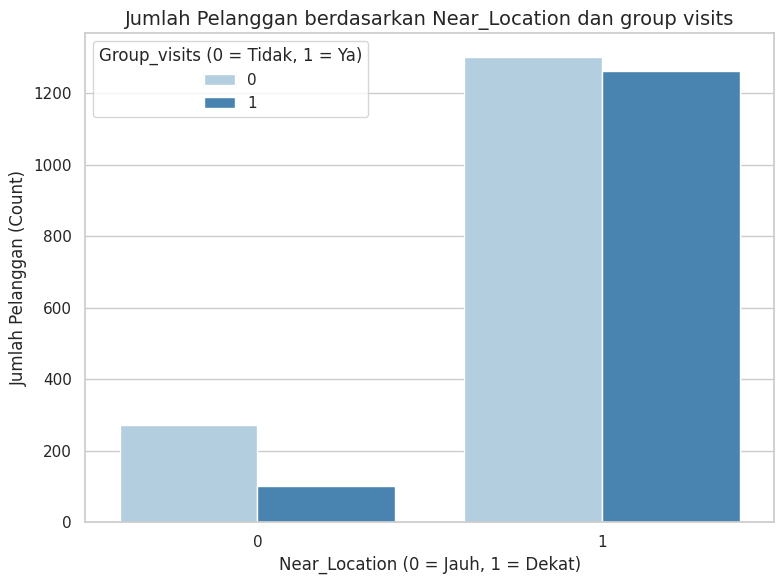

In [ ]:
#buatkan barplotnya loyal near location dengan group
plt.figure(figsize=(8,6))
sns.barplot(
    data=loyal_near_group_counts,
    x='Near_Location',
    y='count',
    hue='Group_visits',
    palette='Blues'
)

plt.title('Jumlah Pelanggan berdasarkan Near_Location dan group visits', fontsize=14)
plt.xlabel('Near_Location (0 = Jauh, 1 = Dekat)')
plt.ylabel('Jumlah Pelanggan (Count)')
plt.legend(title='Group_visits (0 = Tidak, 1 = Ya)')
plt.tight_layout()
plt.show()

terlihat dari jumlah pelanggan loyal yang lokasinya lebih dekat  perbandingan tidak terlalu jauh mereka mengikuti group class, sedangkan yang jauh terlihar sekali perbedaan

###Kontrak vs Lama Bertahan

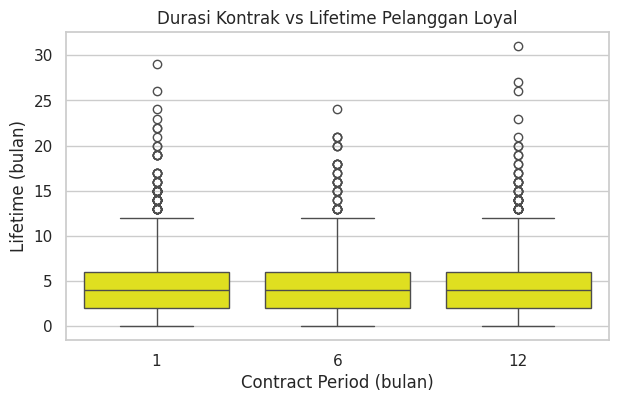

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=loyal, x='Contract_period', y='Lifetime', color='yellow')
plt.title('Durasi Kontrak vs Lifetime Pelanggan Loyal')
plt.xlabel('Contract Period (bulan)')
plt.ylabel('Lifetime (bulan)')
plt.show()

In [ ]:
loyal_near_friend_counts = loyal.groupby('Near_Location')[['Group_visits', 'Promo_friends']].value_counts().reset_index(name='count')
loyal_near_friend_counts

,Near_Location,Group_visits,Promo_friends,count
0,0,0,0,240
1,0,1,0,94
2,0,0,1,32
3,0,1,1,7
4,1,0,0,848
5,1,1,0,718
6,1,1,1,545
7,1,0,1,455


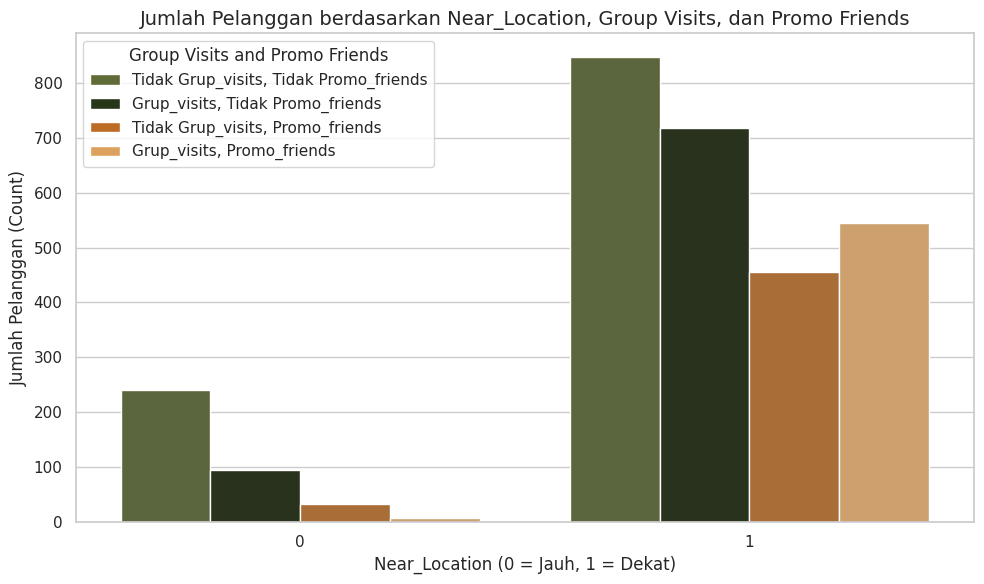

In [ ]:
# Create a combined category for hue
loyal_near_friend_counts['Group_Promo'] = loyal_near_friend_counts['Group_visits'].astype(str) + '_' + loyal_near_friend_counts['Promo_friends'].astype(str)

# buatkan barplotnya loyal near location dengan Promo_friends dan Group_visits
plt.figure(figsize=(10, 6))
sns.barplot(
    data=loyal_near_friend_counts,
    x='Near_Location',
    y='count',
    hue='Group_Promo',
    palette=['#606C38','#283618','#BC6C25','#DDA15E']
)

plt.title('Jumlah Pelanggan berdasarkan Near_Location, Group Visits, dan Promo Friends', fontsize=14)
plt.xlabel('Near_Location (0 = Jauh, 1 = Dekat)')
plt.ylabel('Jumlah Pelanggan (Count)')
# Legend manual (biar 100% sesuai warna)
from matplotlib.patches import Patch
custom_legend = [
    Patch(facecolor="#606C38", label='Tidak Grup_visits, Tidak Promo_friends'),
    Patch(facecolor="#283618", label='Grup_visits, Tidak Promo_friends'),
    Patch(facecolor="#BC6C25", label='Tidak Grup_visits, Promo_friends'),
    Patch(facecolor="#DDA15E", label='Grup_visits, Promo_friends')
]
plt.legend(handles=custom_legend, title='Group Visits and Promo Friends')
plt.tight_layout()
plt.show()

In [ ]:
loyal_near_partner_counts = loyal.groupby('Near_Location')[['Partner', 'Promo_friends']].value_counts().reset_index(name='count')
loyal_near_partner_counts

,Near_Location,Partner,Promo_friends,count
0,0,1,0,173
1,0,0,0,161
2,0,1,1,34
3,0,0,1,5
4,1,0,0,1043
5,1,1,1,840
6,1,1,0,523
7,1,0,1,160


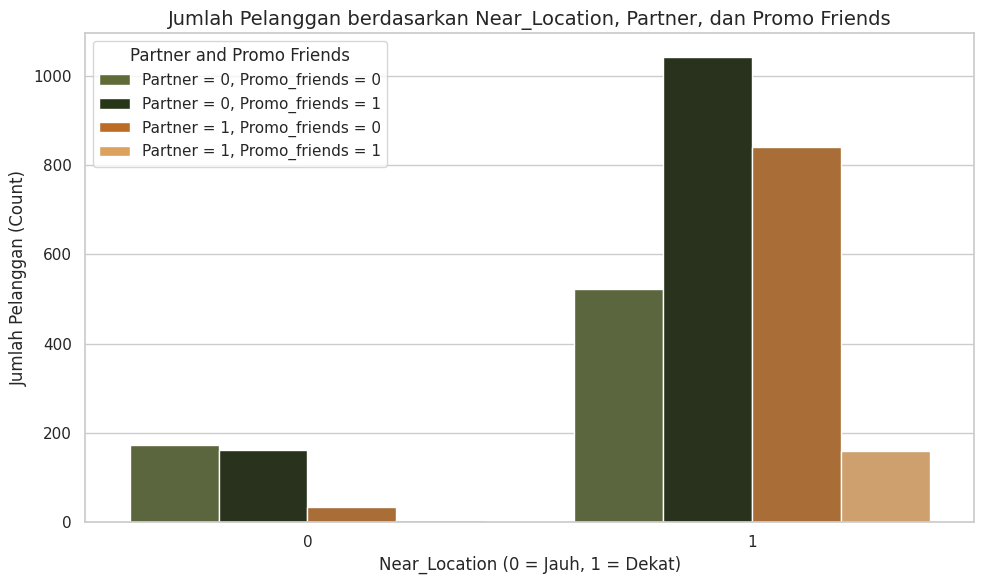

In [ ]:
# Create a combined category for hue
loyal_near_partner_counts['partner_Promo'] = loyal_near_partner_counts['Partner'].astype(str) + '_' + loyal_near_partner_counts['Promo_friends'].astype(str)

# buatkan barplotnya loyal near location dengan partner_Promo dan Group_visits
plt.figure(figsize=(10, 6))
sns.barplot(
    data=loyal_near_partner_counts,
    x='Near_Location',
    y='count',
    hue='partner_Promo',
    palette=['#606C38','#283618','#BC6C25','#DDA15E']
)

plt.title('Jumlah Pelanggan berdasarkan Near_Location, Partner, dan Promo Friends', fontsize=14)
plt.xlabel('Near_Location (0 = Jauh, 1 = Dekat)')
plt.ylabel('Jumlah Pelanggan (Count)')
# Legend manual (biar 100% sesuai warna)
from matplotlib.patches import Patch
custom_legend = [
    Patch(facecolor="#606C38", label='Partner = 0, Promo_friends = 0'),
    Patch(facecolor="#283618", label='Partner = 0, Promo_friends = 1'),
    Patch(facecolor="#BC6C25", label='Partner = 1, Promo_friends = 0'),
    Patch(facecolor="#DDA15E", label='Partner = 1, Promo_friends = 1')
]
plt.legend(handles=custom_legend, title='Partner and Promo Friends')
plt.tight_layout()
plt.show()

In [ ]:
loyal['Promo_friends'] = loyal['Promo_friends'].astype(int)

### lifetime vs group visit vs promo friends

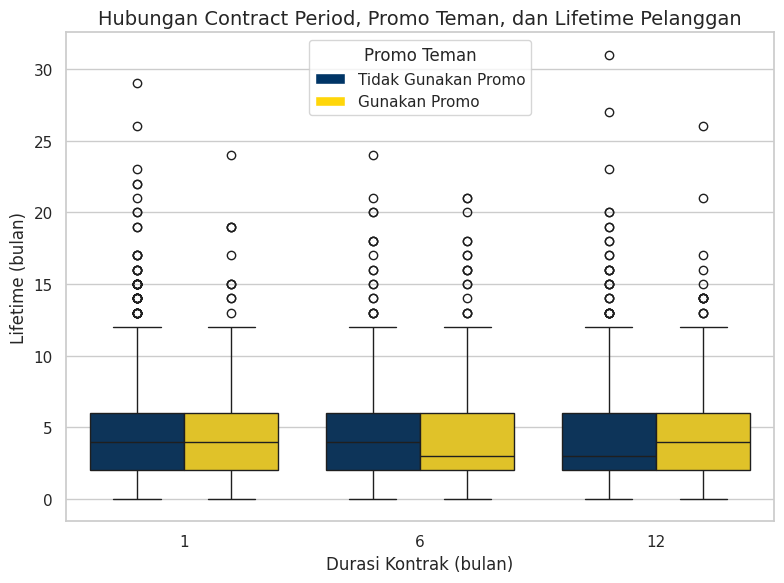

In [ ]:
# Pastikan konsistensi tipe data
loyal['Promo_friends'] = loyal['Promo_friends'].astype(int)
loyal['Contract_period'] = loyal['Contract_period'].astype(int)

# Sort data biar seaborn baca urut
loyal = loyal.sort_values(['Contract_period', 'Promo_friends'])

# Ubah jadi kategori terurut biar seaborn pakai urutan pasti
loyal['Promo_friends'] = pd.Categorical(loyal['Promo_friends'], categories=[0, 1], ordered=True)


plt.figure(figsize=(8,6))
sns.set(style="whitegrid")

# Plot boxplot
sns.boxplot(
    data=loyal,
    x='Contract_period',
    y='Lifetime',
    hue='Promo_friends',
    palette=['#003566','#ffd60a']
)

# Legend manual (biar 100% sesuai warna)
from matplotlib.patches import Patch
custom_legend = [
    Patch(facecolor="#003566", label='Tidak Gunakan Promo'),
    Patch(facecolor="#ffd60a", label='Gunakan Promo')
]
plt.legend(handles=custom_legend, title='Promo Teman')

plt.title('Hubungan Contract Period, Promo Teman, dan Lifetime Pelanggan', fontsize=14)
plt.xlabel('Durasi Kontrak (bulan)', fontsize=12)
plt.ylabel('Lifetime (bulan)', fontsize=12)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi, kontrak yang lebih panjang dan penggunaan promo teman tidak menunjukkan peningkatan signifikan terhadap loyalitas pelanggan (lifetime).
Dengan kata lain, pelanggan dengan kontrak 12 bulan tidak lebih loyal dibanding yang kontraknya 1 atau 6 bulan, bahkan ketika mereka menggunakan promo teman.

### age vs avg class freq total

In [ ]:
#age vs avg class freq total
loyal.groupby('Age')['Avg_class_frequency_total'].value_counts()

Age  Avg_class_frequency_total
19   0.998505                     1
20   0.418440                     1
     2.213092                     1
     2.484111                     1
21   1.148028                     1
                                 ..
38   3.354541                     1
39   1.995093                     1
     3.685728                     1
     4.675341                     1
41   0.324260                     1
Name: count, Length: 2883, dtype: int64

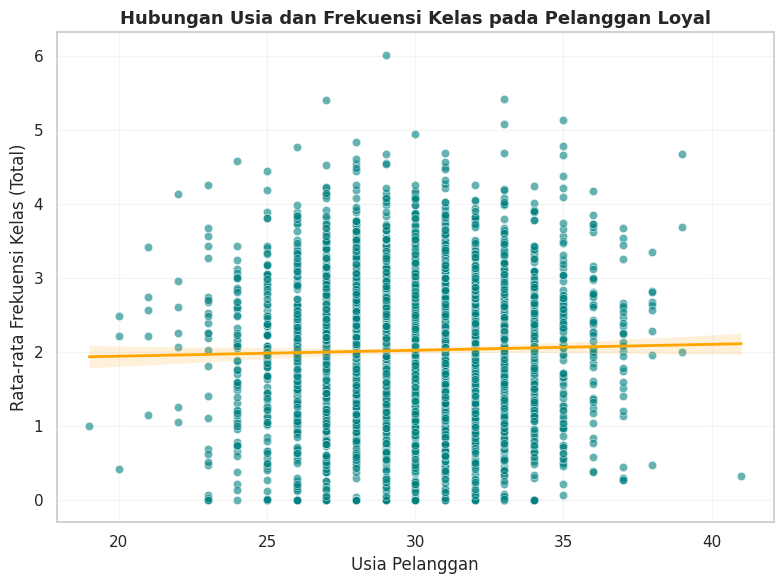

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=loyal,
    x='Age',
    y='Avg_class_frequency_total',
    alpha=0.6,
    color='teal'
)

# --- Tambahkan garis tren ---
sns.regplot(
    data=loyal,
    x='Age',
    y='Avg_class_frequency_total',
    scatter=False,
    color='orange',
    line_kws={'linewidth': 2}
)

# --- Tambahkan judul dan label ---
plt.title('Hubungan Usia dan Frekuensi Kelas pada Pelanggan Loyal', fontsize=13, weight='bold')
plt.xlabel('Usia Pelanggan')
plt.ylabel('Rata-rata Frekuensi Kelas (Total)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

“Frekuensi kelas pelanggan loyal relatif seragam di semua kelompok usia, menunjukkan bahwa partisipasi kelas bukan faktor yang dibedakan oleh umur.”

apakah pelanggan loyal bertahan 6-12 bulan? atau bahkan lebih?

pelanggan loyal terlihat telah bergabung rata-rata masih dibawah 6 bulan

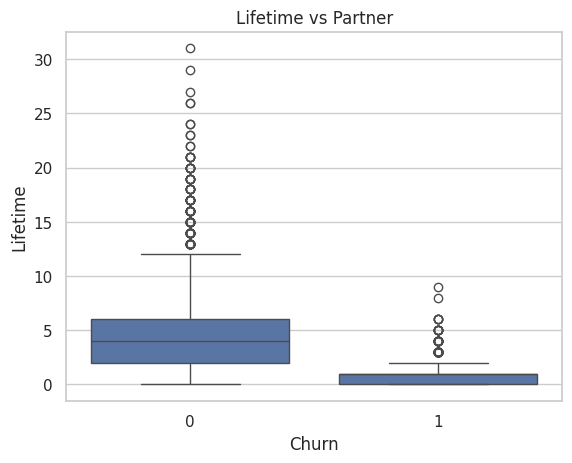

In [ ]:
#lifetime dan churn
sns.boxplot(x='Churn', y='Lifetime', data=df)
plt.title('Lifetime vs Partner')
plt.show()

##Analisis aktivitas sosial pelanggan loyal

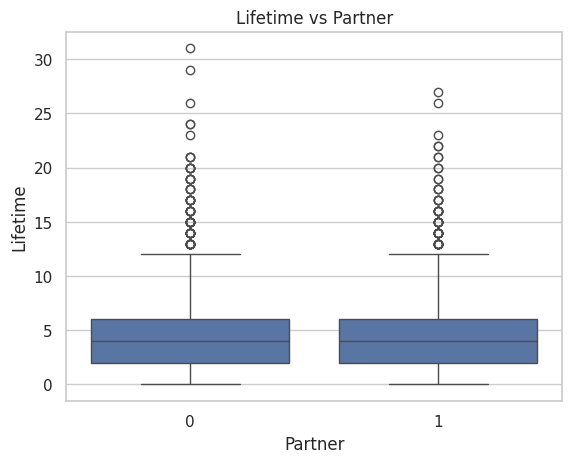

In [ ]:
sns.boxplot(x='Partner', y='Lifetime', data=loyal)
plt.title('Lifetime vs Partner')
plt.show()

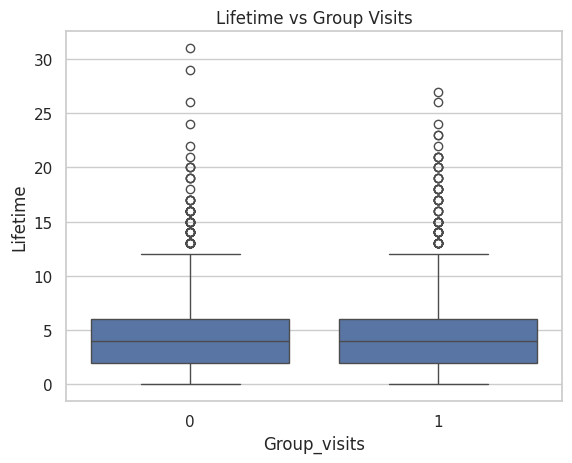

In [ ]:
sns.boxplot(x='Group_visits', y='Lifetime', data=loyal)
plt.title('Lifetime vs Group Visits')
plt.show()


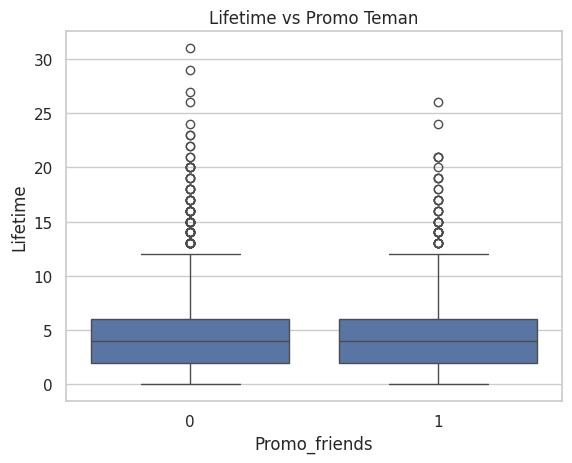

In [ ]:
sns.boxplot(x='Promo_friends', y='Lifetime', data=loyal)
plt.title('Lifetime vs Promo Teman')
plt.show()

,0
Partner,53.419530
Group_visits,46.410344
Promo_friends,35.352161


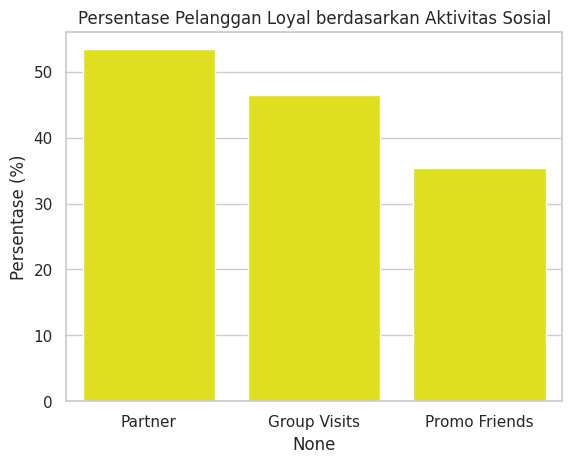

In [ ]:
social_cols = ['Partner', 'Group_visits', 'Promo_friends']

# Convert columns to numeric before calculating the mean
social_means = loyal[social_cols].astype(int).mean().sort_values(ascending=False) * 100
display(social_means)

sns.barplot(x=social_means.index, y=social_means.values, color='yellow')
plt.title('Persentase Pelanggan Loyal berdasarkan Aktivitas Sosial')
plt.ylabel('Persentase (%)')
plt.xticks(ticks=[0, 1, 2], labels=['Partner', 'Group Visits', 'Promo Friends']) # Update x-axis labels
plt.show()

,Near_Location,Social_Activity,Percentage
0,0,Partner,55.495979
1,1,Partner,53.117693
2,0,Group_visits,27.077748
3,1,Group_visits,49.220577
4,0,Promo_friends,10.455764
5,1,Promo_friends,38.971161


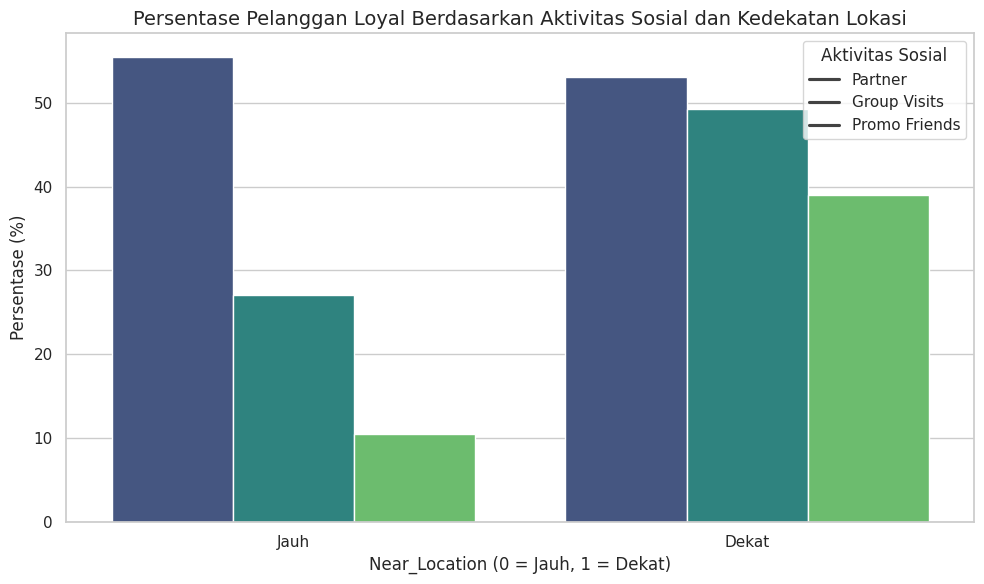

In [ ]:
# Calculate percentages of social activities by Near_Location for loyal customers
# Create a temporary DataFrame with necessary columns and convert to numeric
temp_loyal = loyal[['Near_Location'] + social_cols].copy()
for col in social_cols:
    temp_loyal[col] = temp_loyal[col].astype(int)

social_near_percentage = temp_loyal.groupby('Near_Location')[social_cols].mean() * 100

# Reset index and melt to long format for plotting
social_near_percentage = social_near_percentage.reset_index().melt(id_vars='Near_Location', var_name='Social_Activity', value_name='Percentage')

display(social_near_percentage)

# Create the grouped bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=social_near_percentage,
    x='Near_Location',
    y='Percentage',
    hue='Social_Activity',
    palette='viridis'
)

plt.title('Persentase Pelanggan Loyal Berdasarkan Aktivitas Sosial dan Kedekatan Lokasi', fontsize=14)
plt.xlabel('Near_Location (0 = Jauh, 1 = Dekat)')
plt.ylabel('Persentase (%)')
plt.xticks(ticks=[0, 1], labels=['Jauh', 'Dekat'])
plt.legend(title='Aktivitas Sosial', labels=['Partner', 'Group Visits', 'Promo Friends'])
plt.tight_layout()
plt.show()

In [ ]:
#gabungkan social_cols dengan near_location
social_near_counts = loyal.groupby('Near_Location')[social_cols].value_counts().unstack().fillna(0)
social_near_counts

Promo_friends                         0    1
Near_Location Partner Group_visits          
0             0       0             113    4
                      1              48    1
              1       0             127   28
                      1              46    6
1             0       0             541   67
                      1             502   93
              1       0             307  388
                      1             216  452

terlihat bahwa sekitar
- 53% customer loyal memiiliki partner
- 46% mengikuti group visits
- 35% menggunakan promo teman

,0
Promo_friends,64.647839
Group_visits,53.589656
Partner,46.580470


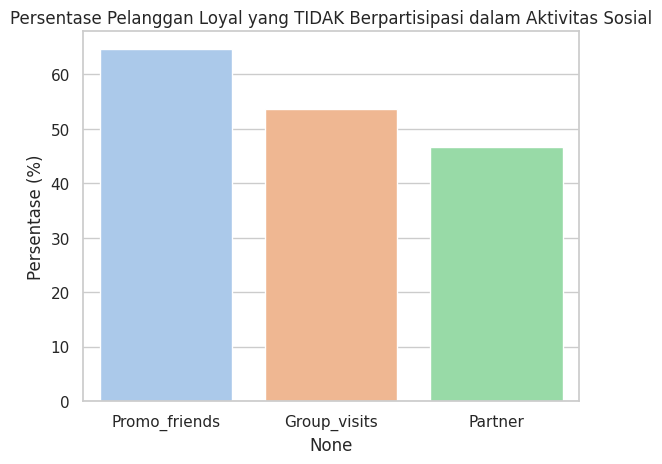

In [ ]:
social_cols = ['Partner', 'Group_visits', 'Promo_friends']
social_non_means = (1 - loyal[social_cols].astype(int).mean()).sort_values(ascending=False) * 100

display(social_non_means)

sns.barplot(x=social_non_means.index, y=social_non_means.values, palette='pastel')
plt.title('Persentase Pelanggan Loyal yang TIDAK Berpartisipasi dalam Aktivitas Sosial')
plt.ylabel('Persentase (%)')
plt.show()

apakah kontrak panjang berkorelasi dengan durasi bertahan lebih lama?

In [ ]:
#ingin melihat distribusi contract period
loyal['Contract_period'].value_counts()

,count
Contract_period,
1,1273
12,937
6,729


Text(0, 0.5, '')

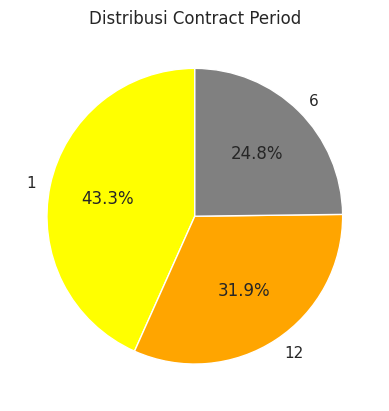

In [ ]:
#dan buatkan boxplotnya distribusi contract period tidak dengan lifetime tp table valuecounts diatas
loyal['Contract_period'].value_counts().plot(kind = 'pie', autopct='%1.1f%%', startangle=90, colors=['yellow','orange', 'gray'])
plt.title('Distribusi Contract Period')
plt.ylabel('')


form here on, i want to see correlation between lifetime of loyal customer and other features

##Lokasi vs Loyalitas

In [ ]:
loyal['Near_Location'].value_counts()

,count
Near_Location,
1,2566
0,373


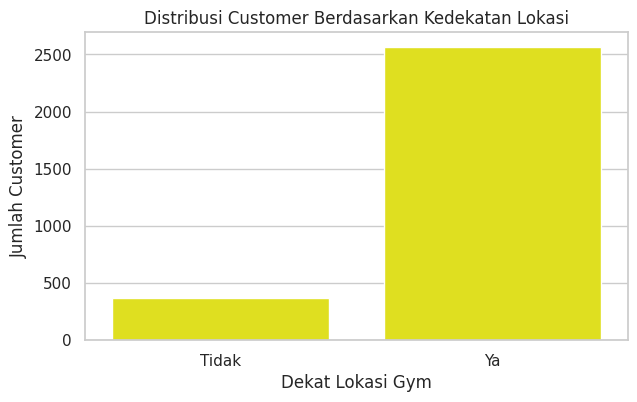

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='Near_Location', data=loyal, color='yellow')
plt.title('Distribusi Customer Berdasarkan Kedekatan Lokasi')
plt.xlabel('Dekat Lokasi Gym')
plt.ylabel('Jumlah Customer')
plt.xticks([0, 1], ['Tidak', 'Ya']) # Assuming 0 is not near and 1 is near
plt.show()

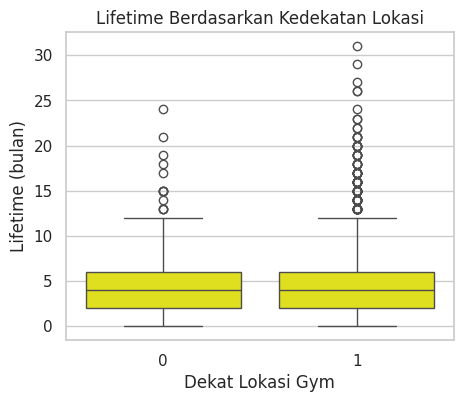

In [ ]:
plt.figure(figsize=(5,4))
sns.boxplot(data=loyal, x='Near_Location', y='Lifetime', color='yellow')
plt.title('Lifetime Berdasarkan Kedekatan Lokasi')
plt.xlabel('Dekat Lokasi Gym')
plt.ylabel('Lifetime (bulan)')
plt.show()


there is no difference avg lifetime between near or not location loyal customer

apakah pelanggan yang jauh justru tetap loyal? ini bisa mengindikasikan faktor lain (kenyamanan, layanan).

 ## Lifetime vs Gender

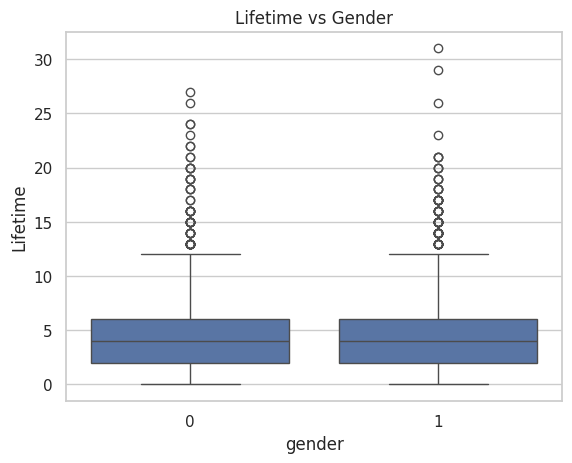

In [ ]:
sns.boxplot(x='gender', y='Lifetime', data=loyal)
plt.title('Lifetime vs Gender')
plt.show()

there is no difference avg lifetime between female and male loyal customer

## Lifetime vs Class Frequency

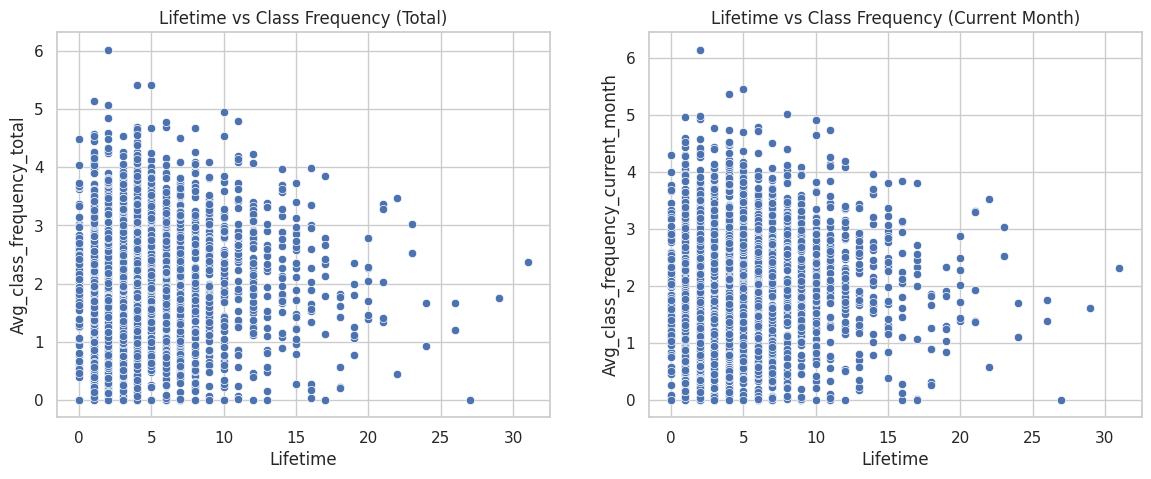

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='Lifetime', y='Avg_class_frequency_total', data=loyal, ax=axes[0])
axes[0].set_title('Lifetime vs Class Frequency (Total)')
sns.scatterplot(x='Lifetime', y='Avg_class_frequency_current_month', data=loyal, ax=axes[1])
axes[1].set_title('Lifetime vs Class Frequency (Current Month)')
plt.show()

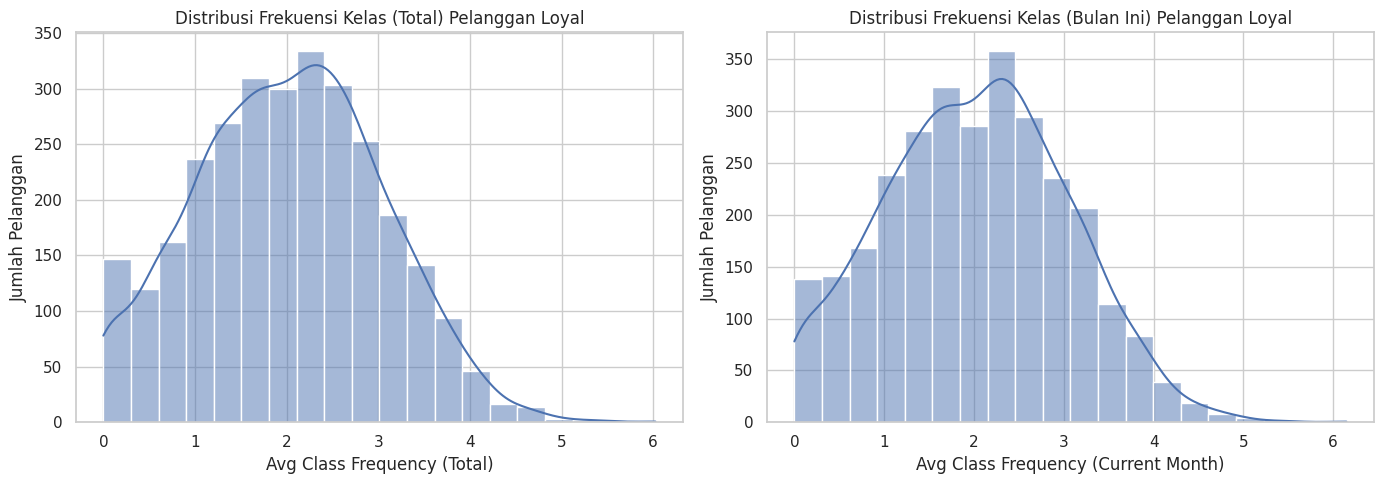

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(loyal['Avg_class_frequency_total'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Frekuensi Kelas (Total) Pelanggan Loyal')
axes[0].set_xlabel('Avg Class Frequency (Total)')
axes[0].set_ylabel('Jumlah Pelanggan')

sns.histplot(loyal['Avg_class_frequency_current_month'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Frekuensi Kelas (Bulan Ini) Pelanggan Loyal')
axes[1].set_xlabel('Avg Class Frequency (Current Month)')
axes[1].set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

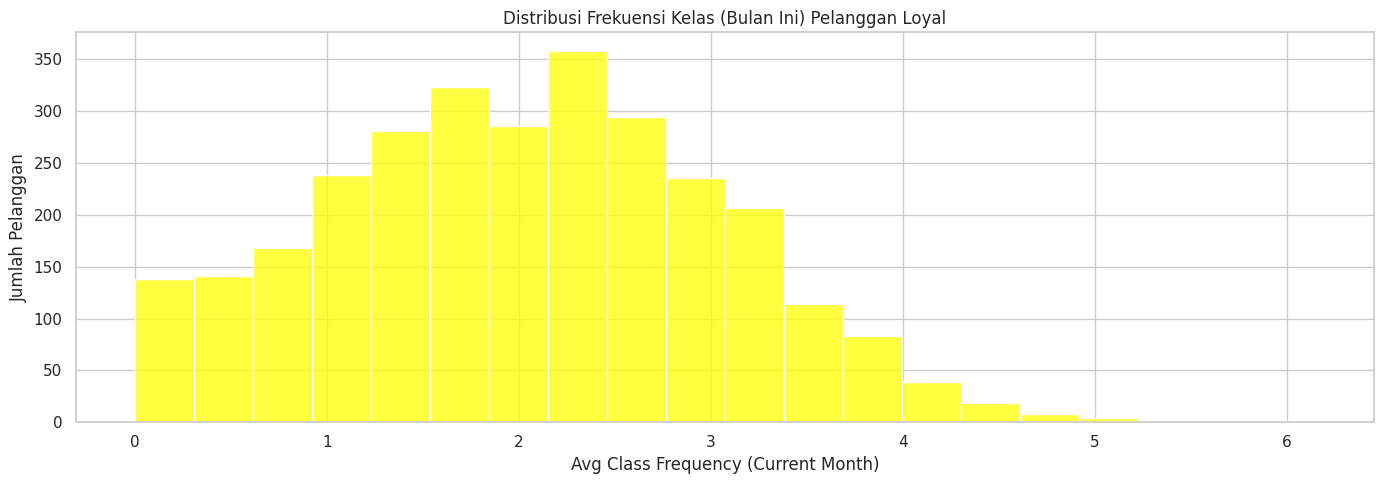

In [ ]:
fig, axes = plt.subplots(figsize=(14, 5)) # Create a single Axes object

sns.histplot(loyal['Avg_class_frequency_current_month'], bins=20, ax=axes, color='yellow') # Plot on the single Axes
axes.set_title('Distribusi Frekuensi Kelas (Bulan Ini) Pelanggan Loyal')
axes.set_xlabel('Avg Class Frequency (Current Month)')
axes.set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

## Lifetime vs Additional Charges

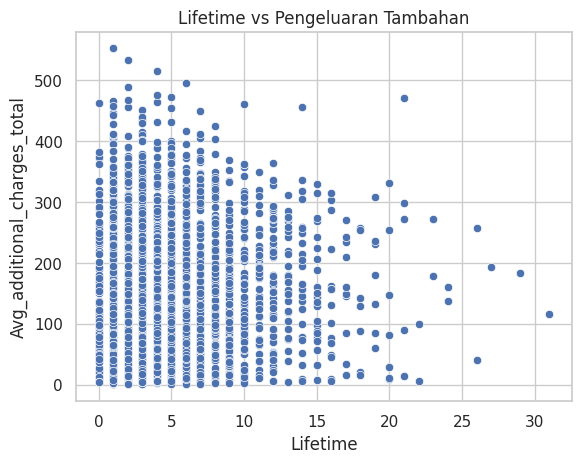

In [ ]:
sns.scatterplot(x='Lifetime', y='Avg_additional_charges_total', data=loyal)
plt.title('Lifetime vs Pengeluaran Tambahan')
plt.show()

as we can see as the customer lifetime increases, the avg additional charges decreasing

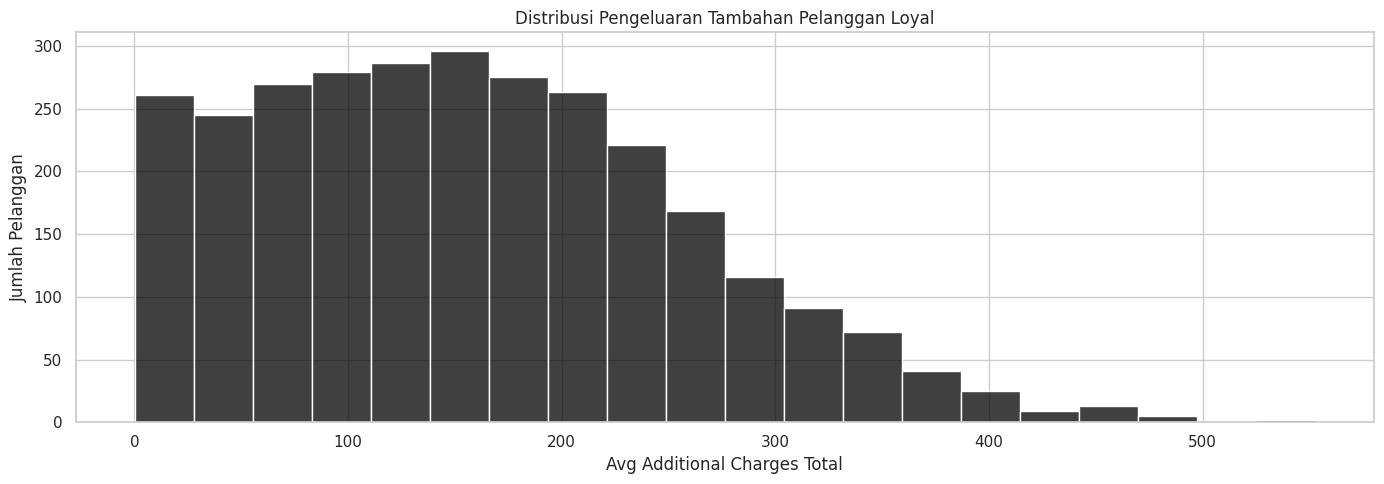

In [ ]:
fig, axes = plt.subplots(figsize=(14, 5)) # Create a single Axes object

sns.histplot(loyal['Avg_additional_charges_total'], bins=20, ax=axes, color='black') # Plot on the single Axes
axes.set_title('Distribusi Pengeluaran Tambahan Pelanggan Loyal')
axes.set_xlabel('Avg Additional Charges Total')
axes.set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

In [ ]:
#melihat distribusi gender dan age oyal dalam tabel
loyal['Avg_additional_charges_total'].value_counts()

,count
Avg_additional_charges_total,
78.250542,1
129.448479,1
450.743960,1
65.310836,1
97.804315,1
...,...
22.331679,1
132.144632,1
277.713652,1


## Lifetime vs Month to End Contract

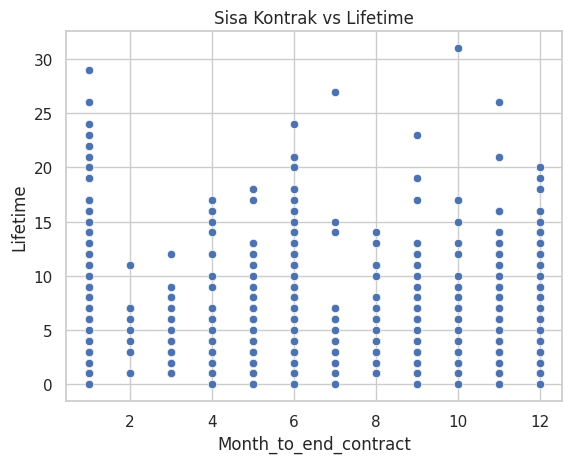

In [ ]:
sns.scatterplot(x='Month_to_end_contract', y='Lifetime', data=loyal)
plt.title('Sisa Kontrak vs Lifetime')
plt.show()

## Lifetime vs Age

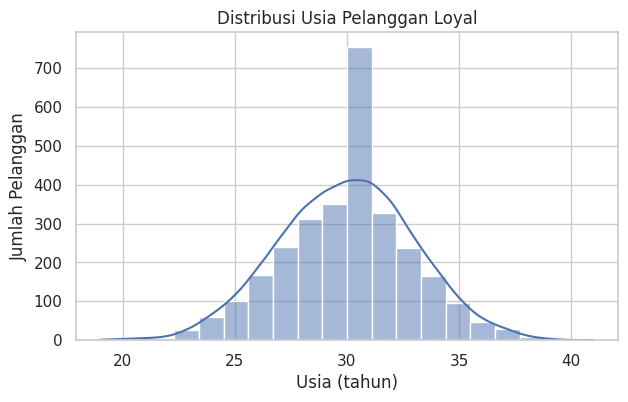

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(loyal['Age'], bins=20, kde=True)
plt.title('Distribusi Usia Pelanggan Loyal')
plt.xlabel('Usia (tahun)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

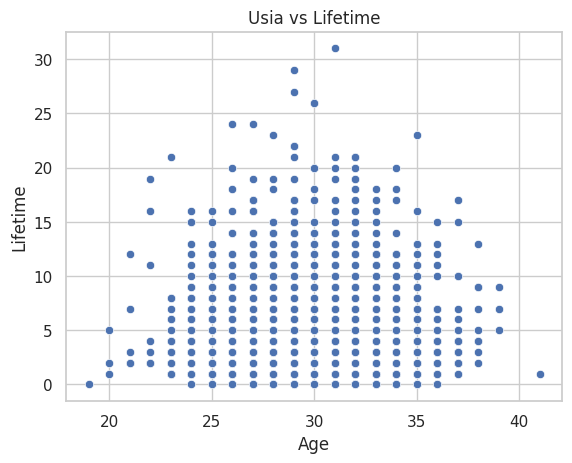

In [ ]:
sns.scatterplot(x='Age', y='Lifetime', data=loyal)
plt.title('Usia vs Lifetime')
plt.show()


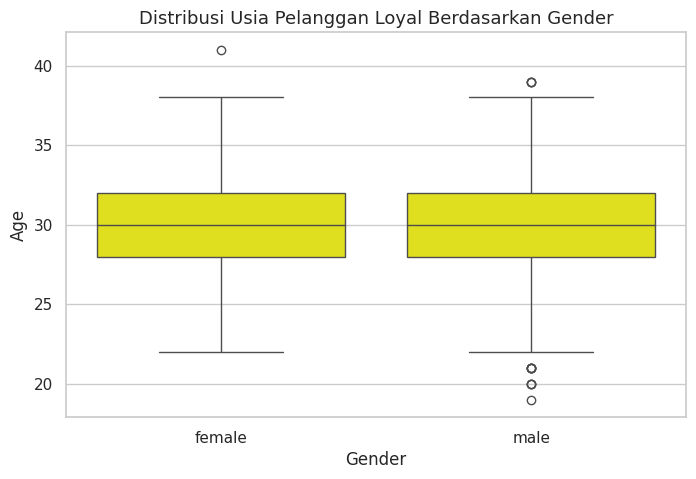

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=loyal, x='gender', y='Age', color='yellow')

plt.title('Distribusi Usia Pelanggan Loyal Berdasarkan Gender', fontsize=13)
plt.xlabel('Gender')
plt.ylabel('Age')
plt.xticks([0, 1], ['female', 'male']) # Change x-axis labels
plt.show()

In [ ]:
#melihat distribusi gender dan age oyal dalam tabel
loyal.groupby('gender')['Age'].value_counts()

gender  Age
0       31     189
        30     188
        29     178
        32     166
        28     150
        33     114
        27     111
        26      84
        34      82
        25      47
        35      44
        24      33
        36      19
        23      17
        37       8
        38       5
        22       4
        41       1
1       31     189
        30     188
        29     171
        32     162
        28     161
        27     128
        33     122
        34      84
        26      83
        25      54
        35      51
        36      29
        24      28
        37      21
        23       9
        21       5
        38       4
        20       3
        22       3
        39       3
        19       1
Name: count, dtype: int64

##Hubungan antar faktor sosial (tanpa bikin variabel baru)

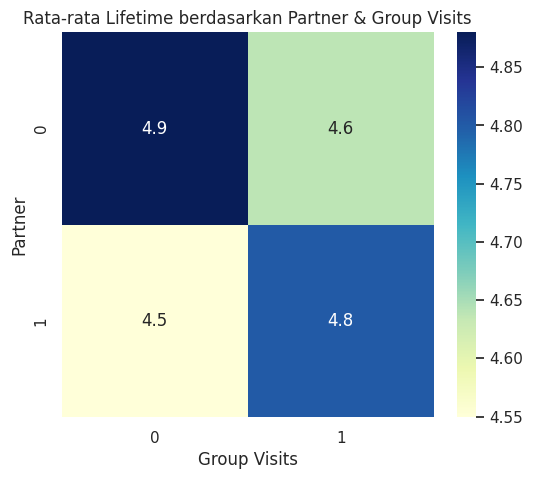

In [ ]:
plt.figure(figsize=(6,5))
heatmap_data = pd.crosstab(loyal['Partner'], loyal['Group_visits'], values=loyal['Lifetime'], aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Rata-rata Lifetime berdasarkan Partner & Group Visits')
plt.xlabel('Group Visits')
plt.ylabel('Partner')
plt.show()

kombinasi perilaku sosial mana yang punya Lifetime tertinggi?

Ringkasan insight sederhana

In [ ]:
summary = pd.DataFrame({
    'Faktor': ['Punya partner', 'Ikut group visit', 'Promo teman', 'Dekat lokasi'],
    'Persentase Loyal (%)': [
        loyal['Partner'].astype(int).mean()*100,
        loyal['Group_visits'].astype(int).mean()*100,
        loyal['Promo_friends'].astype(int).mean()*100,
        loyal['Near_Location'].astype(int).mean()*100
    ]
})
display(summary.round(1))

,Faktor,Persentase Loyal (%)
0,Punya partner,53.4
1,Ikut group visit,46.4
2,Promo teman,35.4
3,Dekat lokasi,87.3


Korelasi antar fitur (loyal subset)

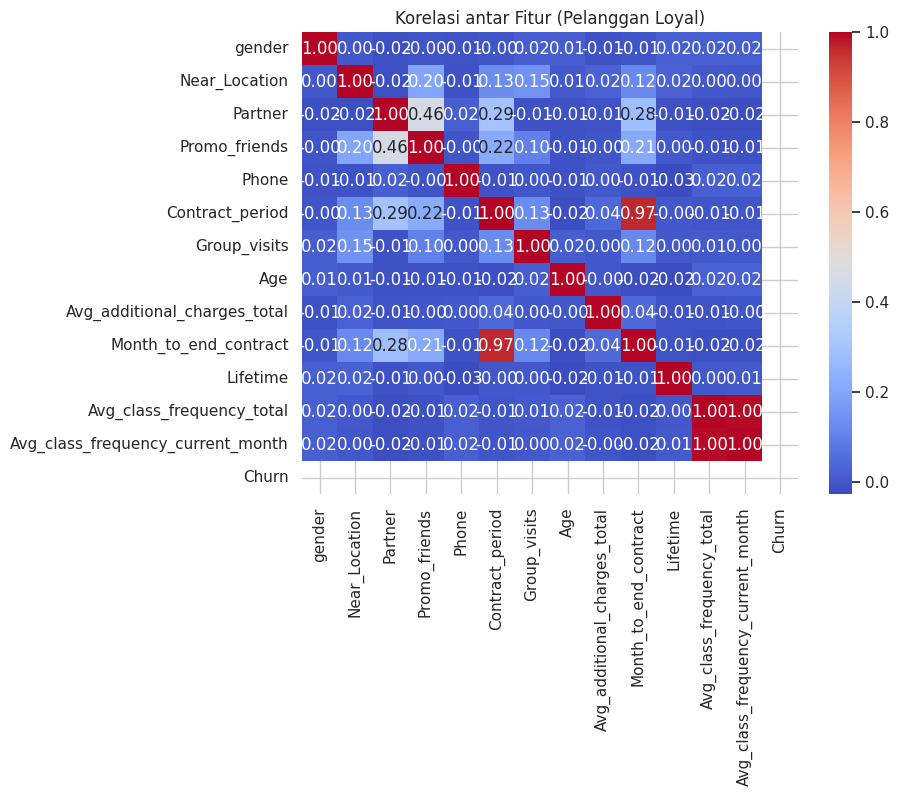

In [ ]:
plt.figure(figsize=(8,6))
# Drop the non-numeric 'freq_category' column before calculating correlation
sns.heatmap(loyal.drop(columns=['freq_category']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi antar Fitur (Pelanggan Loyal)')
plt.show()

# 2. Pembagian Dataset

In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size = 0.2, random_state=42)
#train_df, validation_df = train_test_split(train_df, test_size = 0.2, random_state=42)

In [ ]:
train_df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3994,1,1,0,0,1,1,0,26,31.066721,1,1,1.157451,0.269597,1
423,0,1,0,0,1,6,0,31,144.690532,5,5,1.669950,1.700592,0
2991,0,1,0,0,0,12,0,31,158.273433,12,1,1.064901,1.164403,0
1221,1,1,1,1,1,6,1,33,273.923731,3,12,1.374173,1.365074,0
506,0,1,1,1,1,1,1,34,40.926455,1,4,3.341218,3.305768,0


In [ ]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()

# train
feature_df_train = train_df.drop(['Churn'], axis=1)
target_df_train = train_df['Churn']

# test
feature_df_test = test_df.drop(['Churn'], axis=1)
target_df_test = test_df['Churn']

# Identify numerical columns for scaling
numerical_cols = ['Contract_period', 'Age', 'Avg_additional_charges_total','Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

# One-hot encode categorical columns
feature_df_train = pd.get_dummies(feature_df_train)
# Note: After one-hot encoding, all other columns are already in a numerical format suitable for scaling or are binary (0/1)

# Scale only numerical columns
feature_df_train_scaled_numerical = pd.DataFrame(
    std_scaler.fit_transform(feature_df_train[numerical_cols]),
    columns=numerical_cols,
    index=feature_df_train.index
)

# Combine scaled numerical and non-numerical columns (one-hot encoded)
# Drop the original numerical columns and concatenate the scaled ones
feature_df_train = feature_df_train.drop(columns=numerical_cols).join(feature_df_train_scaled_numerical)

# Scale only numerical columns in the test set using the scaler fitted on the training data
feature_df_test_scaled_numerical = pd.DataFrame(
    std_scaler.transform(feature_df_test[numerical_cols]),
    columns=numerical_cols,
    index=feature_df_test.index
)

# Combine scaled numerical and non-numerical columns (one-hot encoded)
# Drop the original numerical columns and concatenate the scaled ones
feature_df_test = feature_df_test.drop(columns=numerical_cols).join(feature_df_test_scaled_numerical)

In [ ]:
feature_df_train

,gender,Near_Location,Partner,Promo_friends,Phone,Group_visits,Contract_period,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
3994,1,1,0,0,1,0,-0.805487,-0.983689,-1.208398,-0.788319,-0.729186,-0.739683,-1.416051
423,0,1,0,0,1,0,0.290041,0.558748,-0.019463,0.163524,0.355736,-0.211141,-0.054308
2991,0,1,0,0,0,0,1.604674,0.558748,0.122666,1.829248,-0.729186,-0.835130,-0.564548
1221,1,1,1,1,1,1,0.290041,1.175723,1.332806,-0.312398,2.254349,-0.516176,-0.373589
506,0,1,1,1,1,1,-0.805487,1.484210,-1.105228,-0.788319,0.084505,1.512443,1.473186
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,1,1,0,0,1,1,0.290041,-0.366714,-0.927745,0.401484,-0.457956,0.748302,0.834593
1294,1,1,0,0,1,1,-0.805487,-0.058227,-0.097453,-0.788319,-0.729186,0.221596,0.465057
860,0,1,0,0,0,0,-0.805487,-0.366714,-1.181965,-0.788319,-0.729186,-0.521615,-0.321571
3507,0,1,1,1,1,0,1.604674,-1.600664,-1.464986,1.829248,3.339271,-0.328019,0.042757


In [ ]:
# calculate VIF scores for each feature
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(feature_df_train)

vif_df = pd.DataFrame([vif(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns).reset_index()
vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,gender,1.002052
2,Near_Location,1.103819
3,Partner,1.355285
4,Promo_friends,1.359853
5,Phone,1.002606
6,Group_visits,1.064786
7,Contract_period,18.807108
8,Age,1.094573
9,Avg_additional_charges_total,1.032136
10,Month_to_end_contract,18.468095


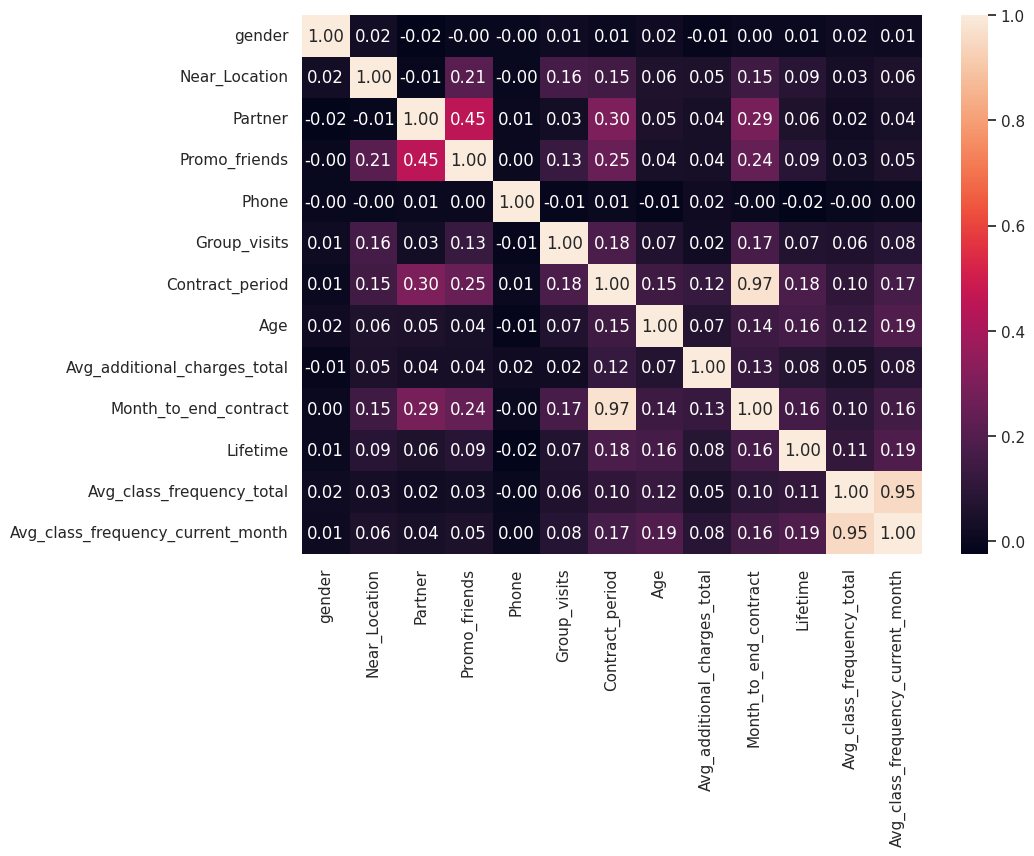

In [ ]:
# heatmap correlation
corr = feature_df_train.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

- kolom month_to_end_contract dan contract_period berkorelasi tinggi
-kolom avg_class_frequency_current_month dan avg_class_frequency_total berkorelasi tinggi

In [ ]:
feature_df_train = feature_df_train.drop(columns=['Month_to_end_contract','Avg_class_frequency_current_month'])
feature_df_test = feature_df_test.drop(columns=['Month_to_end_contract','Avg_class_frequency_current_month'])

In [ ]:
#recheck VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(feature_df_train)

vif_df = pd.DataFrame([vif(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns).reset_index()
vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,gender,1.001683
2,Near_Location,1.103118
3,Partner,1.353514
4,Promo_friends,1.358021
5,Phone,1.001259
6,Group_visits,1.064585
7,Contract_period,1.220925
8,Age,1.057138
9,Avg_additional_charges_total,1.023281
10,Lifetime,1.068008


Semua VIF sudah aman.

# 6. Pelatihan Model dan Hyperparameter Tuning

## Penalized Regression

### Ridge Regression

#### Sebelum Hypertuning

In [ ]:
# define ridge regression model
from sklearn.linear_model import RidgeClassifier

ridge_clf = RidgeClassifier(class_weight='balanced', random_state=42)
ridge_clf.fit(feature_df_train, target_df_train)

RidgeClassifier(class_weight='balanced', random_state=42)

In [ ]:
# train the model
X_df_train = feature_df_train.to_numpy()
y_df_train = target_df_train.to_numpy()
y_df_train = y_df_train.reshape(len(target_df_train),)

# define the model
# 4 models with 4 different alphas (lambda)
ridge_reg_pointzerofive = RidgeClassifier(alpha=0.05, random_state=42)

# fit the model (training)
ridge_reg_pointzerofive.fit(X_df_train, y_df_train)

RidgeClassifier(alpha=0.05, random_state=42)

In [ ]:
ridge_best = ridge_reg_pointzerofive

coef_df = pd.DataFrame({
    'feature':['intercept'] + feature_df_train.columns.tolist(),
    'coefficient':[ridge_best.intercept_] + list(ridge_best.coef_)
})

coef_df

,feature,coefficient
0,intercept,[-0.2969461472141114]
1,gender,0.036248
2,Near_Location,-0.080036
3,Partner,-0.0385
4,Promo_friends,-0.068837
5,Phone,-0.032375
6,Group_visits,-0.11817
7,Contract_period,-0.208381
8,Age,-0.254953
9,Avg_additional_charges_total,-0.105219


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# fungsi evaluasi for regression
def evaluate_regression(model, feature_df_train, target_df_train, feature_df_test, target_df_test):
    # prediksi
    y_pred_train = model.predict(feature_df_train)
    y_pred_test = model.predict(feature_df_test)

    # simpan hasil evaluasi
    results = {
        "Dataset": ["Train", "Test"],
        "RMSE": [
            np.sqrt(mean_squared_error(target_df_train, y_pred_train)),
            np.sqrt(mean_squared_error(target_df_test, y_pred_test))
        ],
        "MAE": [
            mean_absolute_error(target_df_train, y_pred_train),
            mean_absolute_error(target_df_test, y_pred_test)
        ],
        "R-squared": [
            r2_score(target_df_train, y_pred_train),
            r2_score(target_df_test, y_pred_test)
        ]
    }
    return pd.DataFrame(results)

# jalankan evaluasi pakai model terbaik
eval_df = evaluate_regression(
    ridge_reg_pointzerofive,
    feature_df_train, target_df_train,
    feature_df_test, target_df_test
)

display(eval_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but RidgeClassifier was fitted without feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but RidgeClassifier was fitted without feature names



,Dataset,RMSE,MAE,R-squared
0,Train,0.340496,0.115937,0.409623
1,Test,0.346410,0.120000,0.364217


In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_recall_curve

# Prediksi probabilitas (kontinu) dari Ridge
y_pred_train_ridge = ridge_reg_pointzerofive.predict(feature_df_train)

# --- cari threshold optimal berdasarkan F1 atau Recall ---
precisions, recalls, thresholds = precision_recall_curve(target_df_train, y_pred_train_ridge)

# example: choose threshold that gives highest recall with decent precision
optimal_idx = (2 * precisions * recalls) / (precisions + recalls + 1e-6)   # F1-score for each threshold
best_threshold = thresholds[optimal_idx.argmax()]

# convert predictions to classes using the optimal threshold
y_pred_train_ridge_binary = (y_pred_train_ridge >= best_threshold).astype(int)

# Calculate metrics
recall_ridge = recall_score(target_df_train, y_pred_train_ridge_binary)
f1_ridge = f1_score(target_df_train, y_pred_train_ridge_binary)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Recall (Ridge, threshold={best_threshold:.2f}): {recall_ridge:.4f}")
print(f"F1-score (Ridge, threshold={best_threshold:.2f}): {f1_ridge:.4f}")

Best threshold: 1.00
Recall (Ridge, threshold=1.00): 0.7194
F1-score (Ridge, threshold=1.00): 0.7691


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but RidgeClassifier was fitted without feature names



In [ ]:
from sklearn.metrics import classification_report

# Assuming y_pred_test_ridge_binary and target_df_test are already defined from the previous step

print(classification_report(target_df_train, y_pred_train_ridge_binary))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2341
           1       0.83      0.72      0.77       859

    accuracy                           0.88      3200
   macro avg       0.86      0.83      0.85      3200
weighted avg       0.88      0.88      0.88      3200



In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_recall_curve

# Prediksi probabilitas (kontinu) dari Ridge
y_pred_test_ridge = ridge_reg_pointzerofive.predict(feature_df_test)

# --- cari threshold optimal berdasarkan F1 atau Recall ---
precisions, recalls, thresholds = precision_recall_curve(target_df_test, y_pred_test_ridge)

# contoh: pilih threshold yang memberi recall tertinggi dengan precision masih oke
optimal_idx = (2 * precisions * recalls) / (precisions + recalls + 1e-6)   # F1-score tiap threshold
best_threshold = thresholds[optimal_idx.argmax()]

# ubah prediksi ke kelas pakai threshold optimal
y_pred_test_ridge_binary = (y_pred_test_ridge >= best_threshold).astype(int)

# Hitung metrik
recall_ridge = recall_score(target_df_test, y_pred_test_ridge_binary)
f1_ridge = f1_score(target_df_test, y_pred_test_ridge_binary)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Recall (Ridge, threshold={best_threshold:.2f}): {recall_ridge:.4f}")
print(f"F1-score (Ridge, threshold={best_threshold:.2f}): {f1_ridge:.4f}")

Best threshold: 1.00
Recall (Ridge, threshold=1.00): 0.6980
F1-score (Ridge, threshold=1.00): 0.7460


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but RidgeClassifier was fitted without feature names



In [ ]:
from sklearn.metrics import classification_report

# Assuming y_pred_test_ridge_binary and target_df_test are already defined from the previous step

print(classification_report(target_df_test, y_pred_test_ridge_binary))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       598
           1       0.80      0.70      0.75       202

    accuracy                           0.88       800
   macro avg       0.85      0.82      0.83       800
weighted avg       0.88      0.88      0.88       800



#### Setelah Hypertuning

In [ ]:
# tune lambda (denote as 'alpha' in sklearn)
# using GridSearchCV
from sklearn.model_selection import GridSearchCV

# hyperparameter values we want to tune
parameters = {
    'alpha': (0.000001,0.00001,0.0001,0.001,
              0.01, 0.1,0.5, 1, 5, 10, 20)
}

# the tuning
ridge_reg_gridcv = GridSearchCV(ridge_clf, parameters, cv=5,
                                scoring='neg_root_mean_squared_error')
ridge_reg_gridcv.fit(feature_df_train, target_df_train)

GridSearchCV(cv=5,
             estimator=RidgeClassifier(class_weight='balanced',
                                       random_state=42),
             param_grid={'alpha': (1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.5,
                                   1, 5, 10, 20)},
             scoring='neg_root_mean_squared_error')

In [ ]:
# the complete results
pd.DataFrame(ridge_reg_gridcv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.009419,0.001182,0.003752,0.000258,0.000001,{'alpha': 1e-06},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
1,0.008816,0.000281,0.006179,0.005034,0.000010,{'alpha': 1e-05},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
2,0.009371,0.001273,0.003600,0.000133,0.000100,{'alpha': 0.0001},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
3,0.012151,0.004230,0.005097,0.002040,0.001000,{'alpha': 0.001},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
4,0.012270,0.003843,0.004493,0.002157,0.010000,{'alpha': 0.01},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
5,0.008757,0.000319,0.003534,0.000138,0.100000,{'alpha': 0.1},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
6,0.010208,0.002278,0.005359,0.002220,0.500000,{'alpha': 0.5},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
7,0.008247,0.000183,0.003357,0.000224,1.000000,{'alpha': 1},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
8,0.014348,0.009710,0.003793,0.000959,5.000000,{'alpha': 5},-0.397256,-0.377078,-0.383243,-0.38931,-0.431205,-0.395618,0.019004,3
9,0.011631,0.006240,0.003558,0.000141,10.000000,{'alpha': 10},-0.397256,-0.377078,-0.383243,-0.38931,-0.429389,-0.395255,0.018326,1


In [ ]:
# only show the most important columns
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result = pd.DataFrame(ridge_reg_gridcv.cv_results_)
cv_result[retain_cols]

,params,mean_test_score,rank_test_score
0,{'alpha': 1e-06},-0.395618,3
1,{'alpha': 1e-05},-0.395618,3
2,{'alpha': 0.0001},-0.395618,3
3,{'alpha': 0.001},-0.395618,3
4,{'alpha': 0.01},-0.395618,3
5,{'alpha': 0.1},-0.395618,3
6,{'alpha': 0.5},-0.395618,3
7,{'alpha': 1},-0.395618,3
8,{'alpha': 5},-0.395618,3
9,{'alpha': 10},-0.395255,1


**Finding: the best alpha (lambda) is 1e-06**

In [ ]:
# the best model
ridge_reg_gridcv.best_estimator_

RidgeClassifier(alpha=10, class_weight='balanced', random_state=42)

In [ ]:
# the coefficients of the best estimator (exclude intercept)
ridge_reg_gridcv.best_estimator_.coef_

array([ 0.04133454, -0.06067267, -0.02976801, -0.09117658, -0.0395586 ,
       -0.13201995, -0.28546465, -0.26555879, -0.12039565, -0.39501737,
       -0.15298785])

In [ ]:
# the intercept of the best estimator
ridge_reg_gridcv.best_estimator_.intercept_

array([-0.09042049])

In [ ]:
# show as a nice dataframe
coef_df = pd.DataFrame({
    'feature':['intercept'] + feature_df_train.columns.tolist(),
    'coefficient':[ridge_reg_gridcv.best_estimator_.intercept_] + list(ridge_reg_gridcv.best_estimator_.coef_)
})

display(coef_df)

,feature,coefficient
0,intercept,[-0.09042049169527312]
1,gender,0.041335
2,Near_Location,-0.060673
3,Partner,-0.029768
4,Promo_friends,-0.091177
5,Phone,-0.039559
6,Group_visits,-0.13202
7,Contract_period,-0.285465
8,Age,-0.265559
9,Avg_additional_charges_total,-0.120396


Fitur yang memiliki koefisien tetinggi adalah Senior Citizen

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# fungsi evaluasi for regression
def evaluate_regression(model, feature_df_train, target_df_train, feature_df_test, target_df_test):
    # prediksi
    y_pred_train = model.predict(feature_df_train)
    y_pred_test = model.predict(feature_df_test)

    # simpan hasil evaluasi
    results = {
        "Dataset": ["Train", "Test"],
        "RMSE": [
            np.sqrt(mean_squared_error(target_df_train, y_pred_train)),
            np.sqrt(mean_squared_error(target_df_test, y_pred_test))
        ],
        "MAE": [
            mean_absolute_error(target_df_train, y_pred_train),
            mean_absolute_error(target_df_test, y_pred_test)
        ],
        "R-squared": [
            r2_score(target_df_train, y_pred_train),
            r2_score(target_df_test, y_pred_test)
        ]
    }
    return pd.DataFrame(results)

# jalankan evaluasi pakai model terbaik
eval_df = evaluate_regression(
    ridge_reg_gridcv.best_estimator_,
    feature_df_train, target_df_train,
    feature_df_test, target_df_test
)

display(eval_df)

,Dataset,RMSE,MAE,R-squared
0,Train,0.393303,0.154688,0.212300
1,Test,0.406202,0.165000,0.125799


Memakai Threshold 0.5 karena ini adalah threshold default

- Aturan umum: kalau probabilitas ≥ 0.5 → prediksi = 1 (churn).

- Kalau probabilitas < 0.5 → prediksi = 0 (tidak churn).

In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_recall_curve

# Prediksi probabilitas (kontinu) dari Ridge
y_pred_train_ridge = ridge_reg_gridcv.best_estimator_.predict(feature_df_train)

# --- cari threshold optimal berdasarkan F1 atau Recall ---
precisions, recalls, thresholds = precision_recall_curve(target_df_train, y_pred_train_ridge)

# contoh: pilih threshold yang memberi recall tertinggi dengan precision masih oke
optimal_idx = (2 * precisions * recalls) / (precisions + recalls + 1e-6)   # F1-score tiap threshold
best_threshold = thresholds[optimal_idx.argmax()]

# ubah prediksi ke kelas pakai threshold optimal
y_pred_train_ridge_binary = (y_pred_train_ridge >= best_threshold).astype(int)

# Hitung metrik
recall_ridge = recall_score(target_df_train, y_pred_train_ridge_binary)
f1_ridge = f1_score(target_df_train, y_pred_train_ridge_binary)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Recall (Ridge, threshold={best_threshold:.2f}): {recall_ridge:.4f}")
print(f"F1-score (Ridge, threshold={best_threshold:.2f}): {f1_ridge:.4f}")

Best threshold: 1.00
Recall (Ridge, threshold=1.00): 0.9511
F1-score (Ridge, threshold=1.00): 0.7675


In [ ]:
from sklearn.metrics import classification_report

# Assuming y_pred_test_ridge_binary and target_df_test are already defined from the previous step

print(classification_report(target_df_train, y_pred_train_ridge_binary))

              precision    recall  f1-score   support

           0       0.98      0.81      0.88      2341
           1       0.64      0.95      0.77       859

    accuracy                           0.85      3200
   macro avg       0.81      0.88      0.83      3200
weighted avg       0.89      0.85      0.85      3200



In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_recall_curve

# Prediksi probabilitas (kontinu) dari Ridge
y_pred_test_ridge = ridge_reg_gridcv.best_estimator_.predict(feature_df_test)

# --- cari threshold optimal berdasarkan F1 atau Recall ---
precisions, recalls, thresholds = precision_recall_curve(target_df_test, y_pred_test_ridge)

# contoh: pilih threshold yang memberi recall tertinggi dengan precision masih oke
optimal_idx = (2 * precisions * recalls) / (precisions + recalls + 1e-6)   # F1-score tiap threshold
best_threshold = thresholds[optimal_idx.argmax()]

# ubah prediksi ke kelas pakai threshold optimal
y_pred_test_ridge_binary = (y_pred_test_ridge >= best_threshold).astype(int)

# Hitung metrik
recall_ridge = recall_score(target_df_test, y_pred_test_ridge_binary)
f1_ridge = f1_score(target_df_test, y_pred_test_ridge_binary)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Recall (Ridge, threshold={best_threshold:.2f}): {recall_ridge:.4f}")
print(f"F1-score (Ridge, threshold={best_threshold:.2f}): {f1_ridge:.4f}")

Best threshold: 1.00
Recall (Ridge, threshold=1.00): 0.9406
F1-score (Ridge, threshold=1.00): 0.7422


In [ ]:
from sklearn.metrics import classification_report

# Assuming y_pred_test_ridge_binary and target_df_test are already defined from the previous step

print(classification_report(target_df_test, y_pred_test_ridge_binary))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88       598
           1       0.61      0.94      0.74       202

    accuracy                           0.83       800
   macro avg       0.79      0.87      0.81       800
weighted avg       0.88      0.83      0.84       800



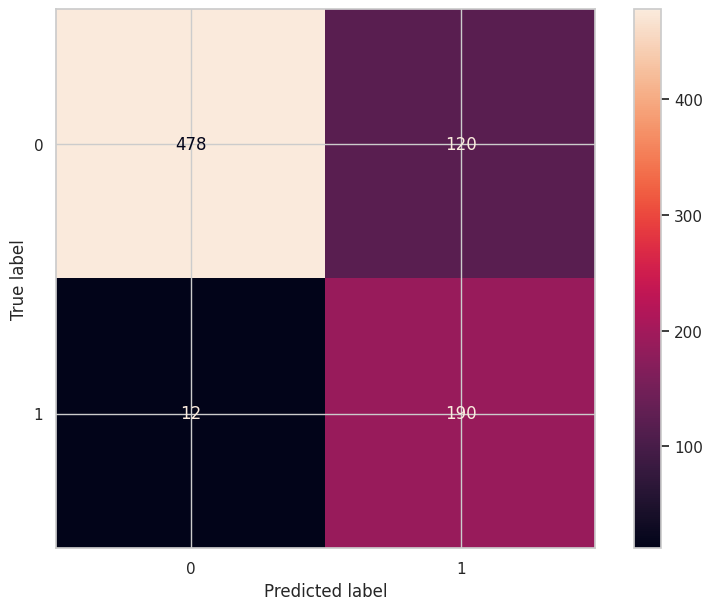

In [ ]:
# the confusion matrix (the best model from gridcv)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,7))

cm = confusion_matrix(target_df_test, y_pred_test_ridge_binary, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=[0, 1])
disp.plot(ax=ax, cmap='rocket')
plt.show()

## K-NN Classification

In [ ]:
# define the estimator/model
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()

#### Sebelum Hypertuning

In [ ]:
knn_clf.fit(feature_df_train, target_df_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn_test = knn_clf.predict(feature_df_test)
y_pred_knn_test

array([0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,

In [ ]:
y_pred_knn_train = knn_clf.predict(feature_df_train)
y_pred_knn_train

array([1, 0, 0, ..., 1, 0, 0])

In [ ]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(target_df_train, y_pred_knn_train))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2341
           1       0.84      0.83      0.84       859

    accuracy                           0.91      3200
   macro avg       0.89      0.89      0.89      3200
weighted avg       0.91      0.91      0.91      3200



In [ ]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(target_df_test, y_pred_knn_test))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       598
           1       0.75      0.74      0.75       202

    accuracy                           0.87       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.87      0.87      0.87       800



#### Setelah Hypertuning

In [ ]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_neighbors': (2,3,4,5,6,7,8)
}

knn_clf_gridcv = GridSearchCV(knn_clf, parameters, cv=5, scoring='recall')
knn_clf_gridcv.fit(feature_df_train, target_df_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': (2, 3, 4, 5, 6, 7, 8)},
             scoring='recall')

In [ ]:
# the compact results
cv_result = pd.DataFrame(knn_clf_gridcv.cv_results_)
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result[retain_cols]

,params,mean_test_score,rank_test_score
0,{'n_neighbors': 2},0.590181,7
1,{'n_neighbors': 3},0.762458,3
2,{'n_neighbors': 4},0.693792,6
3,{'n_neighbors': 5},0.783435,1
4,{'n_neighbors': 6},0.720570,5
5,{'n_neighbors': 7},0.782293,2
6,{'n_neighbors': 8},0.739208,4


Nilai recall tertinggi ada di {'n_neighbors': 5}	dengan 0.505686	. Jadi, model KNN dengan k=5 adalah kandidat terbaik.

### Evaluation metrics on test data

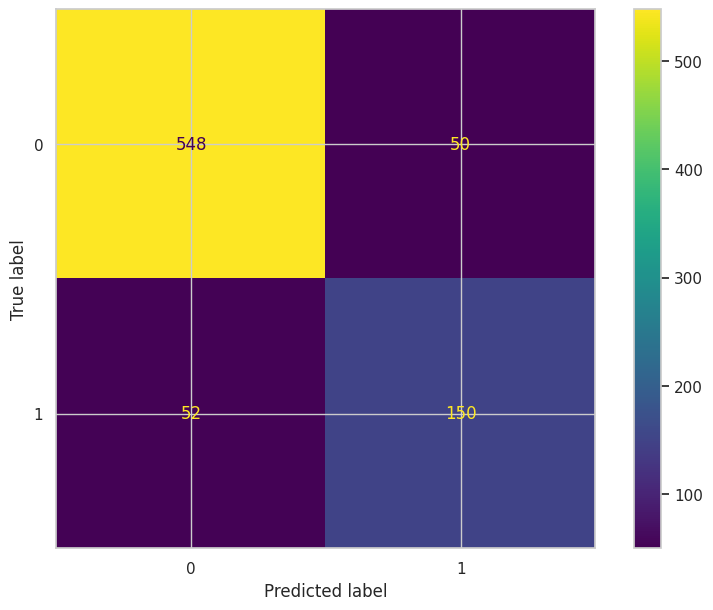

In [ ]:
# plotting confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,7))
y_pred = knn_clf_gridcv.best_estimator_.predict(feature_df_test)

cm = confusion_matrix(target_df_test, y_pred, labels=knn_clf_gridcv.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=knn_clf_gridcv.best_estimator_.classes_)
disp.plot(ax=ax)
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report
y_pred = knn_clf_gridcv.best_estimator_.predict(feature_df_train)
print(classification_report(target_df_train, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2341
           1       0.84      0.83      0.84       859

    accuracy                           0.91      3200
   macro avg       0.89      0.89      0.89      3200
weighted avg       0.91      0.91      0.91      3200



In [ ]:
# classification report
from sklearn.metrics import classification_report
y_pred = knn_clf_gridcv.best_estimator_.predict(feature_df_test)
print(classification_report(target_df_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       598
           1       0.75      0.74      0.75       202

    accuracy                           0.87       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.87      0.87      0.87       800



TIP: Just focus on the row '1'.
<br>
Finding: The recall score on test data is only 0.46.

## Random Forest

In [ ]:
# define random forest classifier model
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

#### Sebelum Hypertuning

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import recall_score, make_scorer

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Definisi scorer untuk F1 score hanya untuk label 1
scorer = make_scorer(recall_score, pos_label=1)

# Melakukan cross-validation dan menghitung skor
scores = cross_val_score(rf_clf, feature_df_train, target_df_train, cv=kf, scoring=scorer)
scores, scores.mean()

(array([0.79069767, 0.75268817, 0.72727273, 0.77922078, 0.7195122 ,
        0.76767677, 0.71428571, 0.7037037 , 0.78888889, 0.77906977]),
 np.float64(0.7523016390074007))

In [ ]:
# Fit the rf_clf model before making predictions
rf_clf.fit(feature_df_train, target_df_train)

preds = rf_clf.predict(feature_df_train)

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, recall_score
cm = confusion_matrix(target_df_train, preds)
cm

array([[2341,    0],
       [   0,  859]])

In [ ]:
# calculate F1 Score
from sklearn.metrics import f1_score
print('F1 Score ',f1_score(target_df_train, preds))

# calculate Recall
from sklearn.metrics import recall_score
print('Recall ',recall_score(target_df_train, preds))

F1 Score  1.0
Recall  1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(target_df_train, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2341
           1       1.00      1.00      1.00       859

    accuracy                           1.00      3200
   macro avg       1.00      1.00      1.00      3200
weighted avg       1.00      1.00      1.00      3200



In [ ]:
preds_test = rf_clf.predict(feature_df_test)

In [ ]:
cm = confusion_matrix(target_df_test, preds_test)
cm

array([[565,  33],
       [ 49, 153]])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(target_df_test, preds_test))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       598
           1       0.82      0.76      0.79       202

    accuracy                           0.90       800
   macro avg       0.87      0.85      0.86       800
weighted avg       0.90      0.90      0.90       800



Random forest is the best prediction model

#### Setelah Hypertuning

In [ ]:
%%time
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_estimators': (100, 200, 300, 400, 500, 600),
    'max_depth':(10, 20, 30)
}

# note: we use recall
rf_clf_gridcv = GridSearchCV(rf_clf, parameters, cv=5, scoring='recall')
rf_clf_gridcv.fit(feature_df_train, target_df_train)

CPU times: user 2min 29s, sys: 305 ms, total: 2min 30s
Wall time: 2min 45s


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': (10, 20, 30),
                         'n_estimators': (100, 200, 300, 400, 500, 600)},
             scoring='recall')

In [ ]:
# the results
cv_result = pd.DataFrame(rf_clf_gridcv.cv_results_)
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result[retain_cols].sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
0,"{'max_depth': 10, 'n_estimators': 100}",0.810227,1
1,"{'max_depth': 10, 'n_estimators': 200}",0.810227,1
3,"{'max_depth': 10, 'n_estimators': 400}",0.809058,3
5,"{'max_depth': 10, 'n_estimators': 600}",0.809058,3
4,"{'max_depth': 10, 'n_estimators': 500}",0.809051,5
2,"{'max_depth': 10, 'n_estimators': 300}",0.805569,6
7,"{'max_depth': 20, 'n_estimators': 200}",0.764763,7
13,"{'max_depth': 30, 'n_estimators': 200}",0.761274,8
16,"{'max_depth': 30, 'n_estimators': 500}",0.761274,8
17,"{'max_depth': 30, 'n_estimators': 600}",0.760118,10


The best max_depth and n_estimator with recall score 0.886288		is
{'max_depth': 1, 'n_estimators': 30}

If we want to speed up the training process, we may use RandomizedSearchCV

In [ ]:
%%time
# using random search CV
from sklearn.model_selection import RandomizedSearchCV

parameters = {
    'n_estimators': [100, 200, 300, 400, 500, 600],  # Rentang ratusan
    # Anda juga dapat menambahkan hyperparameter lain
    'max_depth': [10, 20, 30]
}

rf_clf_randomcv = RandomizedSearchCV(rf_clf, parameters, cv=5,
                                     scoring='recall', n_iter=10)
rf_clf_randomcv.fit(feature_df_train, target_df_train)

CPU times: user 1min 22s, sys: 158 ms, total: 1min 22s
Wall time: 1min 23s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   param_distributions={'max_depth': [10, 20, 30],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600]},
                   scoring='recall')

Now it only takes way less seconds (compared to >5 seconds when using the full GridSearchCV)

In [ ]:
# results of RandomSearchCV
cv_result = pd.DataFrame(rf_clf_randomcv.cv_results_)
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result[retain_cols].sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
1,"{'n_estimators': 200, 'max_depth': 10}",0.810227,1
3,"{'n_estimators': 100, 'max_depth': 10}",0.810227,1
2,"{'n_estimators': 400, 'max_depth': 10}",0.809058,3
5,"{'n_estimators': 200, 'max_depth': 20}",0.764763,4
0,"{'n_estimators': 500, 'max_depth': 30}",0.761274,5
9,"{'n_estimators': 600, 'max_depth': 30}",0.760118,6
7,"{'n_estimators': 600, 'max_depth': 20}",0.758949,7
6,"{'n_estimators': 400, 'max_depth': 30}",0.758949,7
8,"{'n_estimators': 100, 'max_depth': 30}",0.756616,9
4,"{'n_estimators': 400, 'max_depth': 20}",0.756610,10


The best max_depth and n_estimator with recall score 0.886288 is {'max_depth': 1, 'n_estimators': 50}

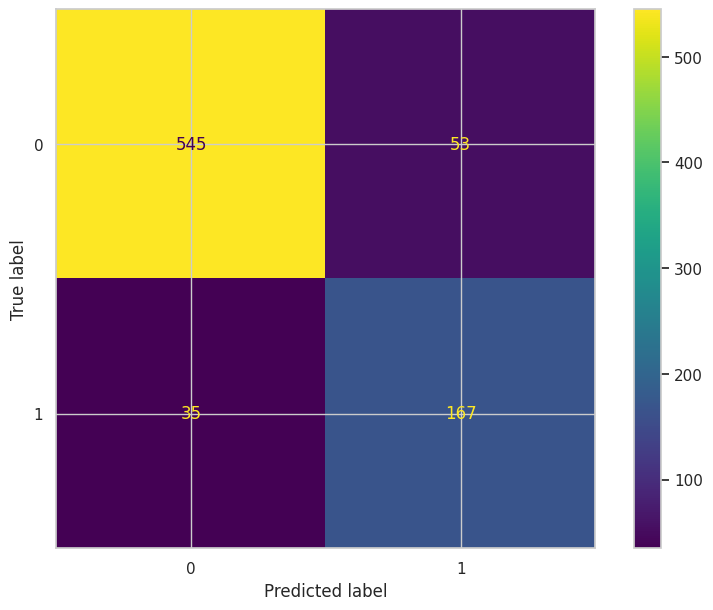

In [ ]:
# the confusion matrix (the best model from gridcv)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,7))
y_pred = rf_clf_gridcv.best_estimator_.predict(feature_df_test)

cm = confusion_matrix(target_df_test, y_pred, labels=rf_clf_gridcv.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf_clf_gridcv.best_estimator_.classes_)
disp.plot(ax=ax)
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report
y_pred = rf_clf_gridcv.best_estimator_.predict(feature_df_train)
print(classification_report(target_df_train, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      2341
           1       0.88      0.99      0.93       859

    accuracy                           0.96      3200
   macro avg       0.94      0.97      0.95      3200
weighted avg       0.97      0.96      0.96      3200



In [ ]:
# classification report
from sklearn.metrics import classification_report
y_pred = rf_clf_gridcv.best_estimator_.predict(feature_df_test)
print(classification_report(target_df_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93       598
           1       0.76      0.83      0.79       202

    accuracy                           0.89       800
   macro avg       0.85      0.87      0.86       800
weighted avg       0.89      0.89      0.89       800



# Model Agnostic Methods

In [ ]:
%pip install dalex

In [ ]:
import dalex as dx
## initiate explainer for XGBoost model
churn_rf_exp = dx.Explainer(rf_clf, feature_df_train, target_df_train, label = "Random Forest Interpretation")

Preparation of a new explainer is initiated

  -> data              : 3200 rows 11 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 3200 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Random Forest Interpretation
  -> predict function  : <function yhat_proba_default at 0x7ad9995d2fc0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0, mean = 0.268, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.39, mean = 0.000322, max = 0.44
  -> model_info        : package sklearn

A new explainer has been created!


## Feature Importance

In [ ]:
# visualize permutation feature importance for XGBoost model
churn_rf_exp.model_parts().plot()

form as we know on eda, that avg lifetime customer still on 1-3 months, so we have to improve the lifetime customer to increasing the overall features.

In [ ]:
### Simpan random forest dan scallernya
import joblib

# simpan model
joblib.dump(rf_clf, "model_churn.pkl")

# simpan scaler
joblib.dump(std_scaler, "scaler.pkl")

# download keduanya
from google.colab import files
files.download("model_churn.pkl")
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from joblib import dump
dump(rf_clf, "model_churn.joblib")


['model_churn.joblib']

In [ ]:
dump(std_scaler, "scaler.joblib")

['scaler.joblib']

In [ ]:
# download keduanya
from google.colab import files
files.download("model_churn.joblib")
files.download("scaler.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip show matplotlib

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [ ]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   int64  
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          40

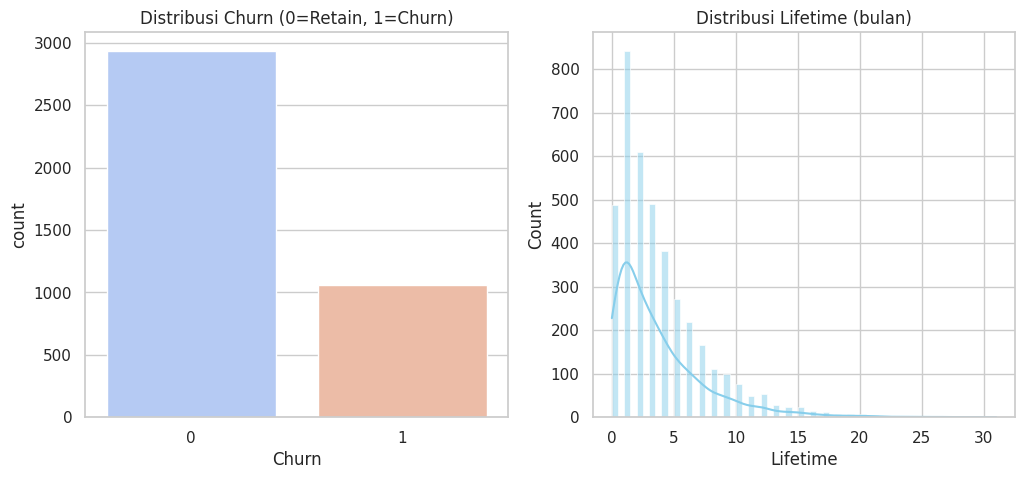

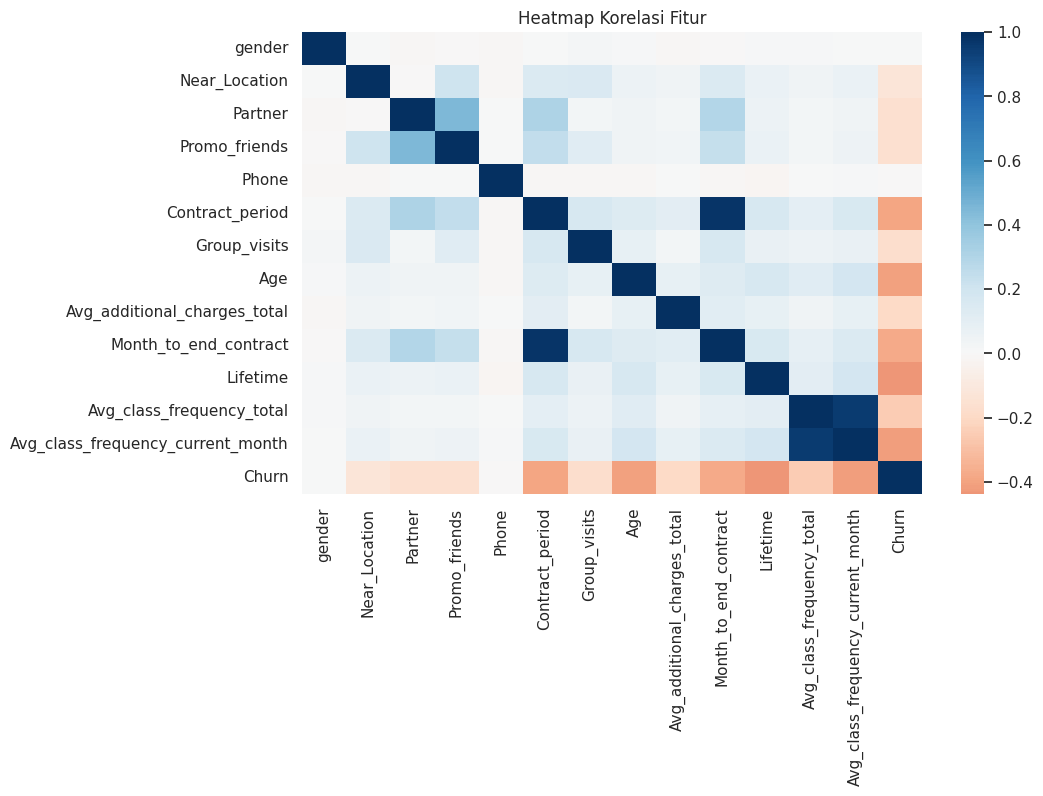

In [ ]:
# 3️⃣ Basic EDA
print("\n--- Data Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isna().sum())

print("\n--- Descriptive Statistics ---")
print(df.describe())

# Distribusi churn dan lifetime
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(data=df, x="Churn", ax=ax[0], palette="coolwarm")
ax[0].set_title("Distribusi Churn (0=Retain, 1=Churn)")

sns.histplot(data=df, x="Lifetime", kde=True, ax=ax[1], color="skyblue")
ax[1].set_title("Distribusi Lifetime (bulan)")
plt.show()

# Korelasi antar fitur numerik
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="RdBu", center=0)
plt.title("Heatmap Korelasi Fitur")
plt.show()


#Churn without lifetime

In [ ]:
df.head( )

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1,3,1.113884,1.120078,0



=== Hasil Model Churn ===
Accuracy: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89       598
           1       0.69      0.60      0.64       202

    accuracy                           0.83       800
   macro avg       0.78      0.75      0.76       800
weighted avg       0.82      0.83      0.83       800



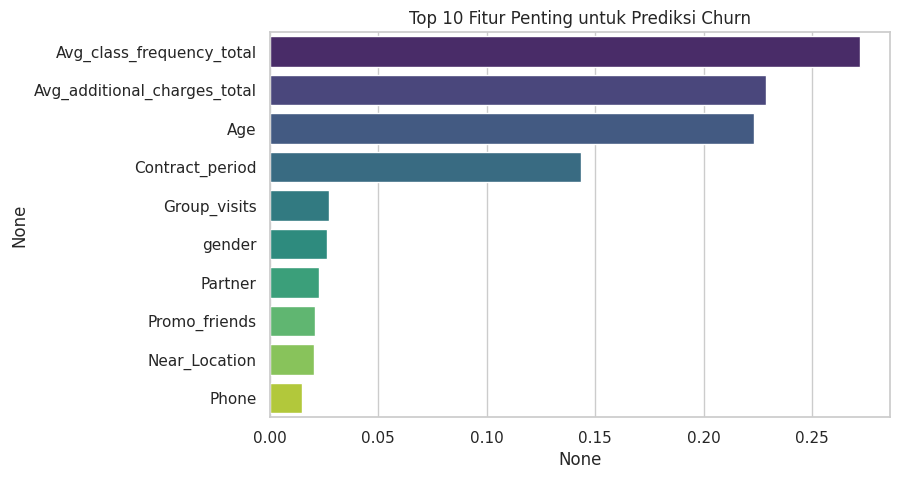

In [ ]:
# 4️⃣ MODEL 1: PREDIKSI CHURN (Classification)
# ===================================================
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pisahkan fitur dan target
X_churn = df.drop(columns=["Churn", "Lifetime"])
y_churn = df["Churn"]

# Split data
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)
#drop multikolinearitas
Xc_train = Xc_train.drop(columns=["Avg_class_frequency_current_month", "Month_to_end_contract"])
Xc_test = Xc_test.drop(columns=["Avg_class_frequency_current_month", "Month_to_end_contract"])
# Train model
clf = RandomForestClassifier(random_state=42)
clf.fit(Xc_train, yc_train)

# Evaluate
yc_pred = clf.predict(Xc_test)
print("\n=== Hasil Model Churn ===")
print("Accuracy:", round(accuracy_score(yc_test, yc_pred), 3))
print("\nClassification Report:\n", classification_report(yc_test, yc_pred))

# Feature importance
imp_churn = pd.Series(clf.feature_importances_, index=Xc_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=imp_churn[:10], y=imp_churn.index[:10], palette="viridis")
plt.title("Top 10 Fitur Penting untuk Prediksi Churn")
plt.show()


=== Hasil Model Lifetime ===
MAE: 2.87
R2 Score: -0.0


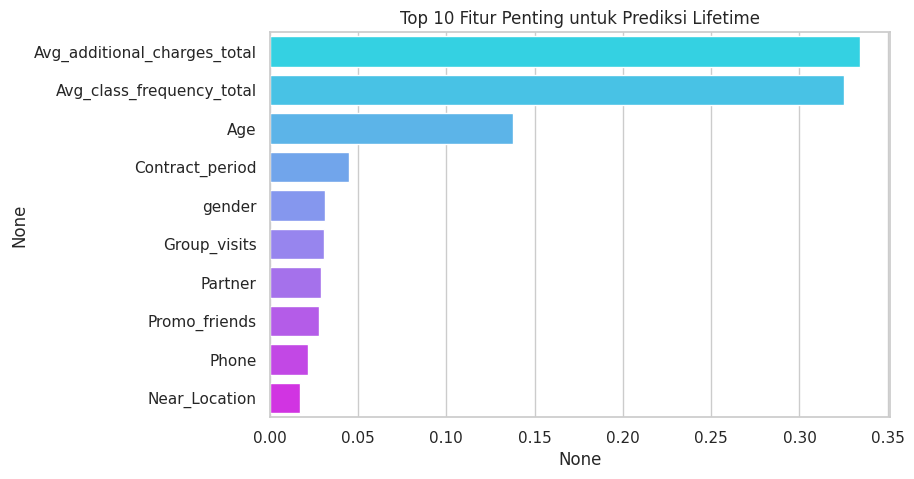

In [ ]:
# ===================================================
# 5️⃣ MODEL 2: PREDIKSI LIFETIME (Regression)
# ===================================================
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score

# Pisahkan fitur dan target
X_life = df.drop(columns=["Lifetime", "Churn"])
y_life = df["Lifetime"]

# Split data
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_life, y_life, test_size=0.2, random_state=42)

# drop multikoleaniritas
Xl_train = Xl_train.drop(columns=["Avg_class_frequency_current_month", "Month_to_end_contract"])
Xl_test = Xl_test.drop(columns=["Avg_class_frequency_current_month", "Month_to_end_contract"])

# Train model
reg = RandomForestRegressor(random_state=42)
reg.fit(Xl_train, yl_train)

# Evaluate
yl_pred = reg.predict(Xl_test)
print("\n=== Hasil Model Lifetime ===")
print("MAE:", round(mean_absolute_error(yl_test, yl_pred), 2))
print("R2 Score:", round(r2_score(yl_test, yl_pred), 2))

# Feature importance
imp_life = pd.Series(reg.feature_importances_, index=Xl_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=imp_life[:10], y=imp_life.index[:10], palette="cool")
plt.title("Top 10 Fitur Penting untuk Prediksi Lifetime")
plt.show()


## ANALISIS GABUNGAN


=== Rata-rata Lifetime Berdasarkan Prediksi Churn ===
Pred_Churn
0    4.500654
1    1.758174
Name: Pred_Lifetime, dtype: float64


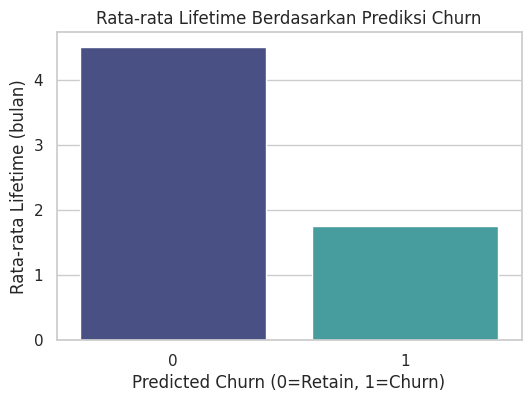

In [ ]:
# ===================================================
# 6️⃣ ANALISIS GABUNGAN
# ===================================================

# Pastikan kolom prediksi sama dengan data training model
X_churn_pred = df.drop(columns=["Churn", "Lifetime", "Avg_class_frequency_current_month", "Month_to_end_contract"])
X_life_pred  = df.drop(columns=["Churn", "Lifetime", "Avg_class_frequency_current_month", "Month_to_end_contract"])

# Prediksi churn & lifetime untuk semua pelanggan
df["Pred_Churn"] = clf.predict(X_churn_pred)
df["Pred_Lifetime"] = reg.predict(X_life_pred)

# Rata-rata lifetime berdasarkan prediksi churn
avg_lifetime_by_churn = df.groupby("Pred_Churn")["Pred_Lifetime"].mean()
print("\n=== Rata-rata Lifetime Berdasarkan Prediksi Churn ===")
print(avg_lifetime_by_churn)

# Visualisasi
plt.figure(figsize=(6,4))
sns.barplot(x=avg_lifetime_by_churn.index, y=avg_lifetime_by_churn.values, palette="mako")
plt.title("Rata-rata Lifetime Berdasarkan Prediksi Churn")
plt.xlabel("Predicted Churn (0=Retain, 1=Churn)")
plt.ylabel("Rata-rata Lifetime (bulan)")
plt.show()


Total pelanggan loyal (prediksi tidak churn): 2965
count    2965.000000
mean        4.500654
std         2.260534
min         0.630000
25%         3.000000
50%         4.020000
75%         5.420000
max        24.930000
Name: Pred_Lifetime, dtype: float64


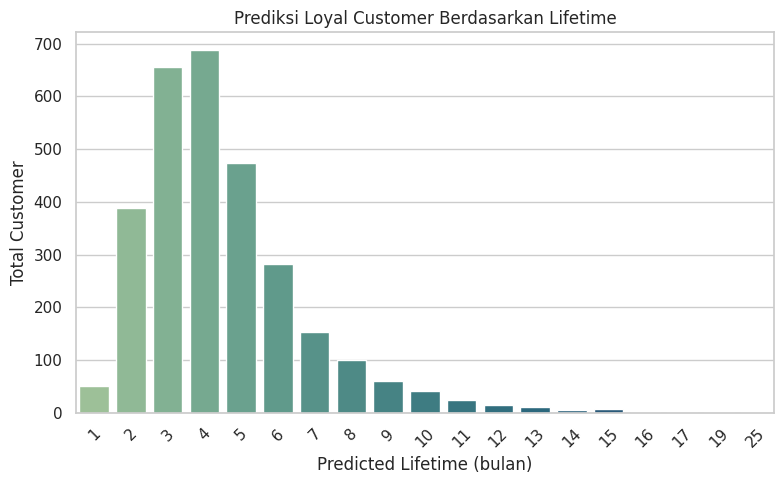

In [ ]:
# ===================================================
# 🔹 ANALISIS PELANGGAN LOYAL BERDASARKAN LIFETIME
# ===================================================

# Filter hanya pelanggan yang diprediksi loyal (tidak churn)
loyal_customers = df[df["Pred_Churn"] == 0]

# Jika ingin melihat ringkasannya
print(f"Total pelanggan loyal (prediksi tidak churn): {len(loyal_customers)}")
print(loyal_customers["Pred_Lifetime"].describe())

# Visualisasi distribusi lifetime pelanggan loyal
plt.figure(figsize=(8,5))
sns.barplot(
    x=loyal_customers["Pred_Lifetime"].round().astype(int).value_counts().index,
    y=loyal_customers["Pred_Lifetime"].round().astype(int).value_counts().values,
    palette="crest"
)
plt.title("Prediksi Loyal Customer Berdasarkan Lifetime")
plt.xlabel("Predicted Lifetime (bulan)")
plt.ylabel("Total Customer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 7️⃣ Insight Ringkas
# ===================================================
print("\n💡 Insight:")
print(f"- Pelanggan yang diprediksi churn memiliki lifetime rata-rata {avg_lifetime_by_churn[1]:.2f} bulan.")
print(f"- Pelanggan yang diprediksi tetap (tidak churn) memiliki lifetime rata-rata {avg_lifetime_by_churn[0]:.2f} bulan.")
print("- Insight ini bisa digunakan untuk mengidentifikasi pelanggan berisiko tinggi dan melakukan strategi retensi lebih awal.")


💡 Insight:
- Pelanggan yang diprediksi churn memiliki lifetime rata-rata 1.76 bulan.
- Pelanggan yang diprediksi tetap (tidak churn) memiliki lifetime rata-rata 4.50 bulan.
- Insight ini bisa digunakan untuk mengidentifikasi pelanggan berisiko tinggi dan melakukan strategi retensi lebih awal.



=== Proporsi Segmentasi Pelanggan ===
Customer_Segment
Moderate        44.78
Loyal           33.60
Rentan Churn    21.62
Name: proportion, dtype: float64


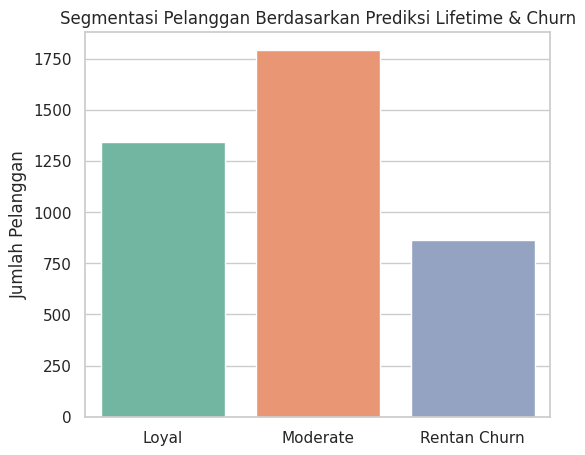

In [ ]:
# ===================================================
# 8️⃣ SEGMENTASI PELANGGAN (Lifetime + Churn)
# ===================================================

# Tentukan batas lifetime (berdasarkan distribusi)
q1 = df["Pred_Lifetime"].quantile(0.33)
q2 = df["Pred_Lifetime"].quantile(0.66)

def segment(row):
    if row["Pred_Churn"] == 1 and row["Pred_Lifetime"] <= q1:
        return "Rentan Churn"
    elif row["Pred_Churn"] == 0 and row["Pred_Lifetime"] >= q2:
        return "Loyal"
    else:
        return "Moderate"

df["Customer_Segment"] = df.apply(segment, axis=1)

# Lihat proporsi tiap segmen
segment_count = df["Customer_Segment"].value_counts(normalize=True) * 100
print("\n=== Proporsi Segmentasi Pelanggan ===")
print(segment_count.round(2))

# Visualisasi segmentasi
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Customer_Segment", palette="Set2", order=["Loyal", "Moderate", "Rentan Churn"])
plt.title("Segmentasi Pelanggan Berdasarkan Prediksi Lifetime & Churn")
plt.xlabel("")
plt.ylabel("Jumlah Pelanggan")
plt.show()

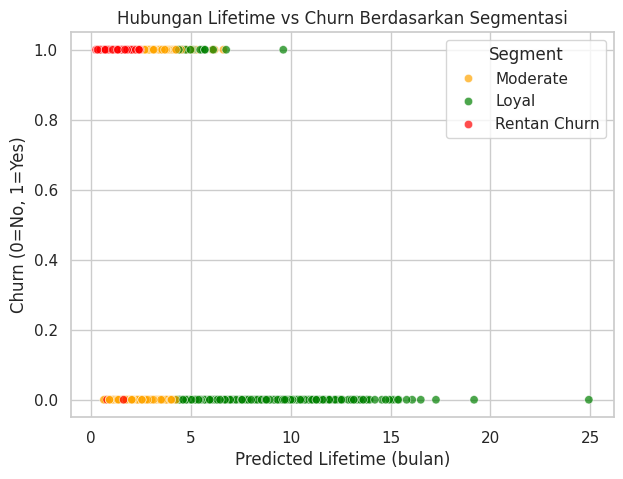

In [ ]:
# Scatter untuk visualisasi hubungan prediksi
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Pred_Lifetime",
    y="Churn",
    hue="Customer_Segment",
    palette={"Loyal": "green", "Moderate": "orange", "Rentan Churn": "red"},
    alpha=0.7
)
plt.title("Hubungan Lifetime vs Churn Berdasarkan Segmentasi")
plt.xlabel("Predicted Lifetime (bulan)")
plt.ylabel("Churn (0=No, 1=Yes)")
plt.legend(title="Segment")
plt.show()

In [ ]:
# 9️⃣ Insight Segmentasi
# ===================================================
print("\n💡 Insight Segmentasi:")
print(f"- {segment_count['Loyal']:.1f}% pelanggan dikategorikan *Loyal* (lifetime tinggi & tidak churn).")
print(f"- {segment_count['Moderate']:.1f}% pelanggan masuk *Moderate* (lifetime sedang atau churn tidak pasti).")
print(f"- {segment_count['Rentan Churn']:.1f}% pelanggan termasuk *Rentan Churn* (lifetime pendek & cenderung churn).")

print("\nRekomendasi Strategi:")
print("• 🎯 Rentan Churn: tawarkan promo loyalitas atau personal reminder sebelum masa kontrak berakhir.")
print("• 😊 Moderate: tingkatkan engagement lewat aktivitas komunitas atau rewards kecil.")
print("• 💎 Loyal: pertahankan dengan program eksklusif dan testimoni positif.")


💡 Insight Segmentasi:
- 33.6% pelanggan dikategorikan *Loyal* (lifetime tinggi & tidak churn).
- 44.8% pelanggan masuk *Moderate* (lifetime sedang atau churn tidak pasti).
- 21.6% pelanggan termasuk *Rentan Churn* (lifetime pendek & cenderung churn).

Rekomendasi Strategi:
• 🎯 Rentan Churn: tawarkan promo loyalitas atau personal reminder sebelum masa kontrak berakhir.
• 😊 Moderate: tingkatkan engagement lewat aktivitas komunitas atau rewards kecil.
• 💎 Loyal: pertahankan dengan program eksklusif dan testimoni positif.


### pake ridge classification, knn classification, dan random forest

In [ ]:
# ===================================================
# 🔹 MODEL 1: PREDIKSI CHURN (Multi-Model Comparison)
# ===================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================
# 1️⃣ Siapkan Data
# ===================================================
X_churn = df.drop(columns=["Churn", "Lifetime"])
y_churn = df["Churn"]

# Split data
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42
)

# Drop fitur dengan multikolinearitas
cols_drop = ["Avg_class_frequency_current_month", "Month_to_end_contract"]
Xc_train = Xc_train.drop(columns=cols_drop)
Xc_test = Xc_test.drop(columns=cols_drop)

# ===================================================
# 2️⃣ Standarisasi Data
# ===================================================
scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

# ===================================================
# 3️⃣ Inisialisasi Model
# ===================================================
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5)
}

# ===================================================
# 4️⃣ Training dan Evaluasi
# ===================================================
results = []

for name, model in models.items():
    model.fit(Xc_train_scaled, yc_train)
    yc_pred = model.predict(Xc_test_scaled)
    acc = accuracy_score(yc_test, yc_pred)

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 3))
    print("Classification Report:\n", classification_report(yc_test, yc_pred))

    results.append({"Model": name, "Accuracy": acc})

# ===================================================
# 5️⃣ Visualisasi Perbandingan Akurasi
# ===================================================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Perbandingan Akurasi Model Prediksi Churn")
plt.xlim(0, 1)
plt.show()


ValueError: could not convert string to float: 'Rentan Churn'

In [ ]:
# ===================================================
# 🔹 MODEL 2: PREDIKSI LIFETIME (Multi-Model Comparison)
# ===================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================
# 1️⃣ Siapkan Data
# ===================================================
X_life = df.drop(columns=["Lifetime", "Churn"])
y_life = df["Lifetime"]

# Split data
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_life, y_life, test_size=0.2, random_state=42
)

# Drop fitur dengan multikolinearitas
cols_drop = ["Avg_class_frequency_current_month", "Month_to_end_contract"]
Xl_train = Xl_train.drop(columns=cols_drop)
Xl_test = Xl_test.drop(columns=cols_drop)

# ===================================================
# 2️⃣ Standarisasi Data
# ===================================================
scaler = StandardScaler()
Xl_train_scaled = scaler.fit_transform(Xl_train)
Xl_test_scaled = scaler.transform(Xl_test)

# ===================================================
# 3️⃣ Inisialisasi Model
# ===================================================
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Ridge Regression": Ridge(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# ===================================================
# 4️⃣ Training dan Evaluasi
# ===================================================
results = []

for name, model in models.items():
    model.fit(Xl_train_scaled, yl_train)
    yl_pred = model.predict(Xl_test_scaled)

    mae = mean_absolute_error(yl_test, yl_pred)
    r2 = r2_score(yl_test, yl_pred)

    print(f"\n=== {name} ===")
    print("MAE :", round(mae, 3))
    print("R²  :", round(r2, 3))

    results.append({"Model": name, "MAE": mae, "R2": r2})

# ===================================================
# 5️⃣ Visualisasi Perbandingan Performa
# ===================================================
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.barplot(x="R2", y="Model", data=results_df, ax=ax[0], palette="cool")
sns.barplot(x="MAE", y="Model", data=results_df, ax=ax[1], palette="crest")

ax[0].set_title("Perbandingan R² Score Model Prediksi Lifetime")
ax[1].set_title("Perbandingan MAE Model Prediksi Lifetime")

plt.tight_layout()
plt.show()
